# Probabilidad Aplicada: Teoria Axiomatica de Kolmogorov

Tratamiento riguroso de la probabilidad desde su formulacion axiomatica (Kolmogorov, 1933) hasta herramientas modernas de machine learning probabilistico, con aplicaciones computacionales.

**Ejes tematicos:**

- Fundamentos axiomaticos y teoria de la medida
- Distribuciones, funciones generadoras y funciones caracteristicas
- Teoremas limite: LGN, TCL, modos de convergencia
- Copulas y modelado de dependencia
- Martingalas y teorema de parada opcional
- Cadenas de Markov y migracion de ratings
- Teoria de valores extremos (GEV)
- Aplicaciones: riesgo crediticio, finanzas cuantitativas y clima
- **Deep Learning Bayesiano e incertidumbre epistémica**
- **Autoencoders Variacionales (VAE) y el ELBO**
- **Normalizing Flows y estimación de densidad**
- **Modelos de difusión probabilísticos**
- **Predicción conformal y cuantificación de incertidumbre**

**Audiencia:** estudiantes de matematica aplicada, economia cuantitativa, ingenieria, ciencias de datos.

**Prerequisitos:** calculo en una variable, algebra lineal basica, nocion de conjuntos, Python elemental.

**Al finalizar seras capaz de:**

1. Definir formalmente un espacio de probabilidad $(\Omega, \mathcal{F}, P)$ y una $\sigma$-algebra.
2. Derivar y aplicar las reglas de probabilidad desde los axiomas.
3. Actualizar creencias con Bayes y entender la actualizacion secuencial.
4. Modelar dependencia mas alla de la correlacion usando copulas.
5. Calcular MGFs, derivar momentos y demostrar el TCL via funciones caracteristicas.
6. Distinguir los modos de convergencia y sus relaciones jerarquicas.
7. Construir y analizar martingalas, aplicar el teorema de parada de Doob.
8. Modelar transiciones de ratings con cadenas de Markov.
9. Ajustar distribuciones GEV y calcular periodos de retorno no estacionarios.
10. Implementar redes neuronales bayesianas y cuantificar incertidumbre epistémica vs aleatórica.
11. Construir VAEs, derivar el ELBO y diagnosticar posterior collapse.
12. Implementar normalizing flows (RealNVP) para estimación de densidad exacta.
13. Entender y simular modelos de difusión (DDPM) desde la perspectiva de score matching.
14. Aplicar predicción conformal para garantías de cobertura distribution-free.
15. Resolver problemas aplicados en riesgo, finanzas y clima.

**Ruta del cuaderno**

1. Espacio de probabilidad, $\sigma$-algebras y axiomas
2. Reglas derivadas y eventos compuestos
3. Probabilidad condicional, Bayes y actualizacion secuencial
4. Independencia, dependencia y copulas
5. Variables aleatorias, distribuciones, MGF y funcion caracteristica
6. De Kolmogorov a la probabilidad moderna: convergencia, TCL, martingalas
7. Aplicaciones: riesgo, finanzas (VaR/ES), clima, Markov, EVT
8. Paradojas clasicas (Monty Hall, Simpson, San Petersburgo)
9. Cierre clásico y mapa de la probabilidad moderna
10. **Deep Learning Bayesiano: BNNs, MC Dropout y Deep Ensembles**
11. **Autoencoders Variacionales (VAE) y la frontera ELBO**
12. **Normalizing Flows y estimación de densidad**
13. **Modelos de difusión probabilísticos (DDPM, Score-SDE)**
14. **Predicción conformal y cuantificación de incertidumbre**
15. Ejercicios guiados

In [6]:
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy import stats
from scipy.integrate import quad
from scipy.optimize import minimize_scalar
from scipy.linalg import expm
import sympy as sp
from sympy import symbols, Function, diff, simplify, exp, sqrt, pi, oo, Rational
from sympy import latex, Eq, solve as sp_solve, integrate, factorial
from IPython.display import display, Math, Markdown
from statistics import NormalDist
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 12,
    'figure.dpi': 100,
    'text.usetex': False,
})

print('Entorno listo: numpy, pandas, matplotlib, seaborn, scipy.stats y sympy cargados.')

Entorno listo: numpy, pandas, matplotlib, seaborn, scipy.stats y sympy cargados.


## 1. El lenguaje de Kolmogorov

### 1.1 El espacio de probabilidad

La formulacion moderna de la probabilidad (Kolmogorov, 1933) parte de una **terna**:

$$(\Omega, \mathcal{F}, P)$$

donde:

- $\Omega$ es el **espacio muestral**: el conjunto de todos los resultados posibles.
- $\mathcal{F}$ es una **$\sigma$-algebra** sobre $\Omega$: la coleccion de eventos a los que podemos asignar probabilidad.
- $P: \mathcal{F} \to [0,1]$ es una **medida de probabilidad**.

### 1.2 $\sigma$-algebras: la estructura de la informacion

**Definicion formal:** Una coleccion $\mathcal{F} \subseteq 2^\Omega$ es una $\sigma$-algebra si:

1. $\Omega \in \mathcal{F}$
2. Si $A \in \mathcal{F}$, entonces $A^c \in \mathcal{F}$ (cerrada bajo complemento)
3. Si $A_1, A_2, \ldots \in \mathcal{F}$, entonces $\bigcup_{i=1}^{\infty} A_i \in \mathcal{F}$ (cerrada bajo uniones numerables)

**Ejemplos fundamentales:**

| $\sigma$-algebra | Descripcion | Interpretacion |
|---|---|---|
| $\{\emptyset, \Omega\}$ | Trivial | Sin informacion |
| $2^\Omega$ | Partes de $\Omega$ | Informacion completa |
| $\sigma(X)$ | Generada por $X$ | Informacion revelada por $X$ |
| $\mathcal{B}(\mathbb{R})$ | Borel en $\mathbb{R}$ | Generada por intervalos abiertos |

La **$\sigma$-algebra de Borel** $\mathcal{B}(\mathbb{R})$ es la menor $\sigma$-algebra que contiene todos los intervalos abiertos de $\mathbb{R}$. Es el marco natural para variables aleatorias continuas.

### 1.3 Los axiomas de Kolmogorov

La medida $P$ satisface:

1. **No negatividad:** $P(A) \geq 0$ para todo $A \in \mathcal{F}$
2. **Normalizacion:** $P(\Omega) = 1$
3. **$\sigma$-aditividad:** si $A_1, A_2, \ldots$ son mutuamente disjuntos ($A_i \cap A_j = \emptyset$ para $i \neq j$), entonces
   $$P\left(\bigcup_{i=1}^{\infty} A_i\right) = \sum_{i=1}^{\infty} P(A_i)$$

**Por que $\sigma$-aditividad y no solo aditividad finita?** La aditividad finita no garantiza continuidad de la medida: sin $\sigma$-aditividad, podriamos tener sucesiones de eventos $A_n \downarrow \emptyset$ con $P(A_n) \not\to 0$, lo cual contradice la intuicion y destruye la conexion con el calculo integral.

### 1.4 La conexion con la teoria de la medida

La probabilidad es un **caso especial** de medida: una medida $\mu$ sobre $(\Omega, \mathcal{F})$ con la restriccion $\mu(\Omega) = 1$.

La **integral de Lebesgue** generaliza la esperanza:

$$E[X] = \int_\Omega X(\omega) \, dP(\omega)$$

Esta perspectiva unifica probabilidad discreta y continua bajo un solo marco, y es la base de la probabilidad moderna (filtraciones, martingalas, movimiento browniano).

In [7]:
escenarios = pd.DataFrame(
    {
        'escenario': ['expansion_estable', 'inflacion_persistente', 'recesion_severa', 'evento_climatico_extremo'],
        'mercado': ['estable', 'volatil', 'estresado', 'estresado'],
        'clima': ['normal', 'normal', 'normal', 'extremo'],
        'prob': [0.50, 0.22, 0.18, 0.10],
    }
)

def prob_event(mask):
    return float(escenarios.loc[mask, 'prob'].sum())

print(escenarios)
print(f"\nP(Omega) = {escenarios['prob'].sum():.2f}")


                  escenario    mercado    clima  prob
0         expansion_estable    estable   normal  0.50
1     inflacion_persistente    volatil   normal  0.22
2           recesion_severa  estresado   normal  0.18
3  evento_climatico_extremo  estresado  extremo  0.10

P(Omega) = 1.00


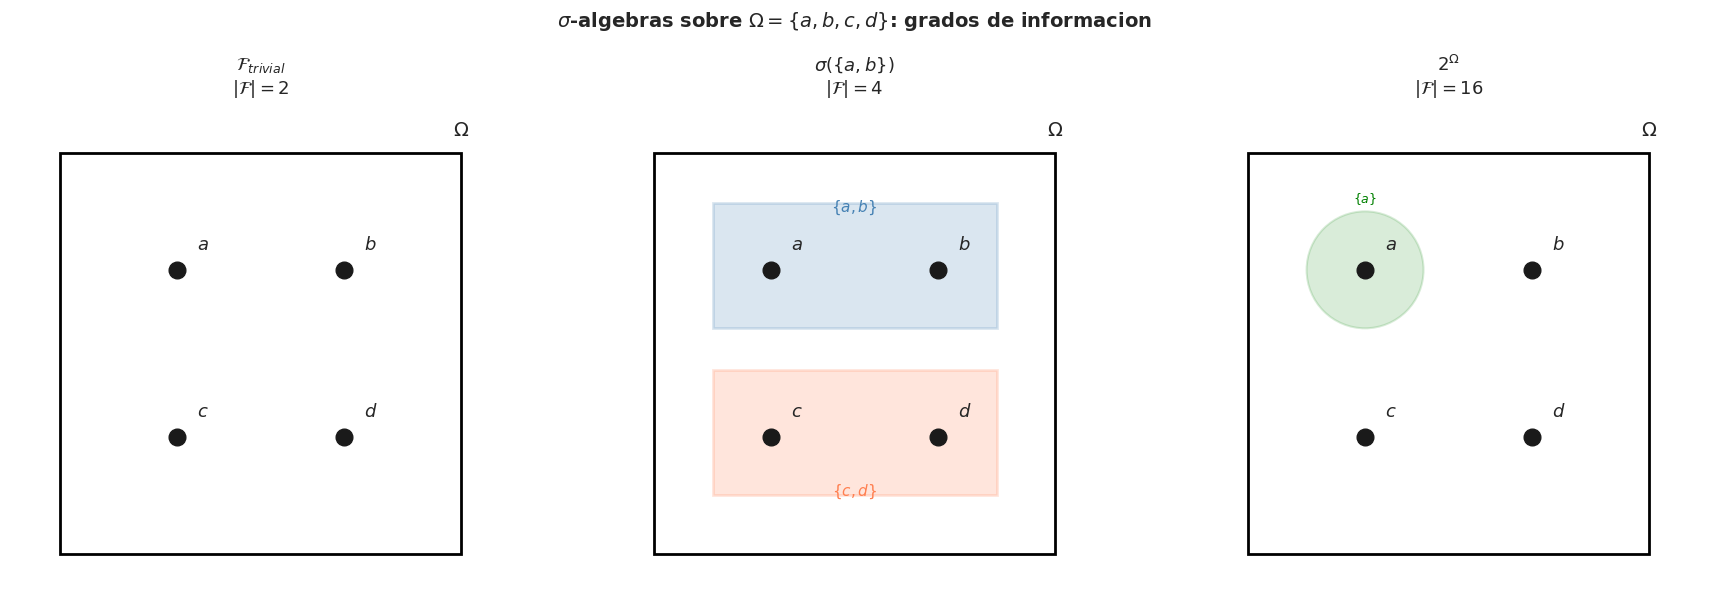

Interpretacion:
  Trivial: solo sabemos si 'algo paso' o no — cero informacion
  σ({a,b}): distinguimos si el resultado esta en {a,b} o en {c,d}
  2^Ω: distinguimos cada resultado individual — informacion completa

  Para |Ω| = 4: la σ-algebra completa tiene 2^4 = 16 elementos


In [8]:
# --- Visualizacion: sigma-algebras y estructura de informacion ---

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Omega = {a, b, c, d} para ilustrar
omega = {'a', 'b', 'c', 'd'}

# sigma-algebra trivial
sa_trivial = [set(), {'a','b','c','d'}]
# sigma-algebra generada por {a,b}
sa_parcial = [set(), {'a','b'}, {'c','d'}, {'a','b','c','d'}]
# sigma-algebra completa (2^Omega)
sa_completa = []
omega_list = list(omega)
for r in range(len(omega_list)+1):
    for combo in combinations(omega_list, r):
        sa_completa.append(set(combo))

# Dibujo: diagrama de Venn simplificado
for ax, sa, titulo, n_events in [(axes[0], sa_trivial, '$\\mathcal{F}_{trivial}$\n$|\\mathcal{F}| = 2$', 2),
                                    (axes[1], sa_parcial, '$\\sigma(\\{a,b\\})$\n$|\\mathcal{F}| = 4$', 4),
                                    (axes[2], sa_completa, '$2^\\Omega$\n$|\\mathcal{F}| = 16$', 16)]:
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Omega como rectangulo
    rect = plt.Rectangle((-1.2, -1.2), 2.4, 2.4, fill=False, edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(1.15, 1.3, '$\\Omega$', fontsize=14, fontweight='bold')
    
    # Elementos de Omega
    positions = {'a': (-0.5, 0.5), 'b': (0.5, 0.5), 'c': (-0.5, -0.5), 'd': (0.5, -0.5)}
    for elem, pos in positions.items():
        ax.plot(*pos, 'ko', markersize=12)
        ax.text(pos[0]+0.12, pos[1]+0.12, f'${elem}$', fontsize=13, fontweight='bold')
    
    # Marcar subconjuntos medibles
    if n_events == 4:
        # Resaltar {a,b} y {c,d}
        rect_ab = plt.Rectangle((-0.85, 0.15), 1.7, 0.75, fill=True, alpha=0.2, 
                                 facecolor='steelblue', edgecolor='steelblue', linewidth=2)
        rect_cd = plt.Rectangle((-0.85, -0.85), 1.7, 0.75, fill=True, alpha=0.2,
                                 facecolor='coral', edgecolor='coral', linewidth=2)
        ax.add_patch(rect_ab)
        ax.add_patch(rect_cd)
        ax.text(0, 0.85, '$\\{a,b\\}$', ha='center', fontsize=11, color='steelblue')
        ax.text(0, -0.85, '$\\{c,d\\}$', ha='center', fontsize=11, color='coral')
    elif n_events == 16:
        # Mostrar algunos subconjuntos
        circle = plt.Circle((-0.5, 0.5), 0.35, fill=True, alpha=0.15, facecolor='green', edgecolor='green', linewidth=1.5)
        ax.add_patch(circle)
        ax.text(-0.5, 0.9, '$\\{a\\}$', ha='center', fontsize=9, color='green')
    
    ax.set_title(titulo, fontsize=13, fontweight='bold')

plt.suptitle('$\\sigma$-algebras sobre $\\Omega = \\{a, b, c, d\\}$: grados de informacion',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Interpretacion:")
print("  Trivial: solo sabemos si 'algo paso' o no — cero informacion")
print("  σ({a,b}): distinguimos si el resultado esta en {a,b} o en {c,d}")
print("  2^Ω: distinguimos cada resultado individual — informacion completa")
print(f"\n  Para |Ω| = 4: la σ-algebra completa tiene 2^4 = {2**4} elementos")

## 2. Reglas derivadas de los axiomas

De los axiomas se deducen reglas fundamentales:

- **Complemento:** $P(A^c) = 1 - P(A)$.
- **Monotonia:** si $A \subseteq B$, entonces $P(A) \le P(B)$.
- **Union de dos eventos:**
  $$P(A \cup B) = P(A) + P(B) - P(A \cap B).$$
- **Continuidad:** si una sucesion de eventos crece o decrece de forma monotona, la probabilidad converge al limite adecuado.

Estas identidades son el puente entre la teoria abstracta y la practica analitica diaria.


In [9]:
A = escenarios['mercado'] == 'estresado'
B = escenarios['clima'] == 'extremo'

pA = prob_event(A)
pB = prob_event(B)
pAc = prob_event(~A)
p_inter = prob_event(A & B)
p_union = prob_event(A | B)
p_union_formula = pA + pB - p_inter

resumen_eventos = pd.DataFrame(
    {
        'evento': ['A = mercado estresado', 'B = clima extremo', 'A complemento', 'A interseccion B', 'A union B'],
        'probabilidad': [pA, pB, pAc, p_inter, p_union],
    }
)

print(resumen_eventos)
print(f"\nComplemento: P(A^c) = {pAc:.2f} y 1 - P(A) = {1 - pA:.2f}")
print(f"Union: P(A U B) = {p_union:.2f} y por formula = {p_union_formula:.2f}")


                  evento  probabilidad
0  A = mercado estresado          0.28
1      B = clima extremo          0.10
2          A complemento          0.72
3       A interseccion B          0.10
4              A union B          0.28

Complemento: P(A^c) = 0.72 y 1 - P(A) = 0.72
Union: P(A U B) = 0.28 y por formula = 0.28


## 3. Probabilidad condicional, ley total y Bayes

Si $P(B) > 0$, la probabilidad condicional se define como

$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}.
$$

La **ley de probabilidad total** y el **teorema de Bayes** permiten actualizar creencias cuando observamos evidencia.

En analisis de riesgo, esto es clave: no basta con conocer la tasa base de incumplimiento; necesitamos revisar esa probabilidad cuando aparecen senales tempranas.


In [10]:
prior = {'alto': 0.18, 'medio': 0.37, 'bajo': 0.45}
p_alerta = {'alto': 0.65, 'medio': 0.30, 'bajo': 0.08}

p_total_alerta = sum(prior[k] * p_alerta[k] for k in prior)
posterior_alerta = {
    k: prior[k] * p_alerta[k] / p_total_alerta
    for k in prior
}

p_total_sin_alerta = 1 - p_total_alerta
posterior_sin_alerta = {
    k: prior[k] * (1 - p_alerta[k]) / p_total_sin_alerta
    for k in prior
}

tabla_bayes = pd.DataFrame(
    {
        'prior': pd.Series(prior),
        'P(alerta | perfil)': pd.Series(p_alerta),
        'P(perfil | alerta)': pd.Series(posterior_alerta),
        'P(perfil | sin_alerta)': pd.Series(posterior_sin_alerta),
    }
)

print(tabla_bayes.round(4))
print(f"\nP(alerta) = {p_total_alerta:.4f}")
print(f"Si hay alerta, la probabilidad de perfil alto sube a {posterior_alerta['alto']:.2%}.")


       prior  P(alerta | perfil)  P(perfil | alerta)  P(perfil | sin_alerta)
alto    0.18                0.65              0.4432                  0.0856
medio   0.37                0.30              0.4205                  0.3519
bajo    0.45                0.08              0.1364                  0.5625

P(alerta) = 0.2640
Si hay alerta, la probabilidad de perfil alto sube a 44.32%.


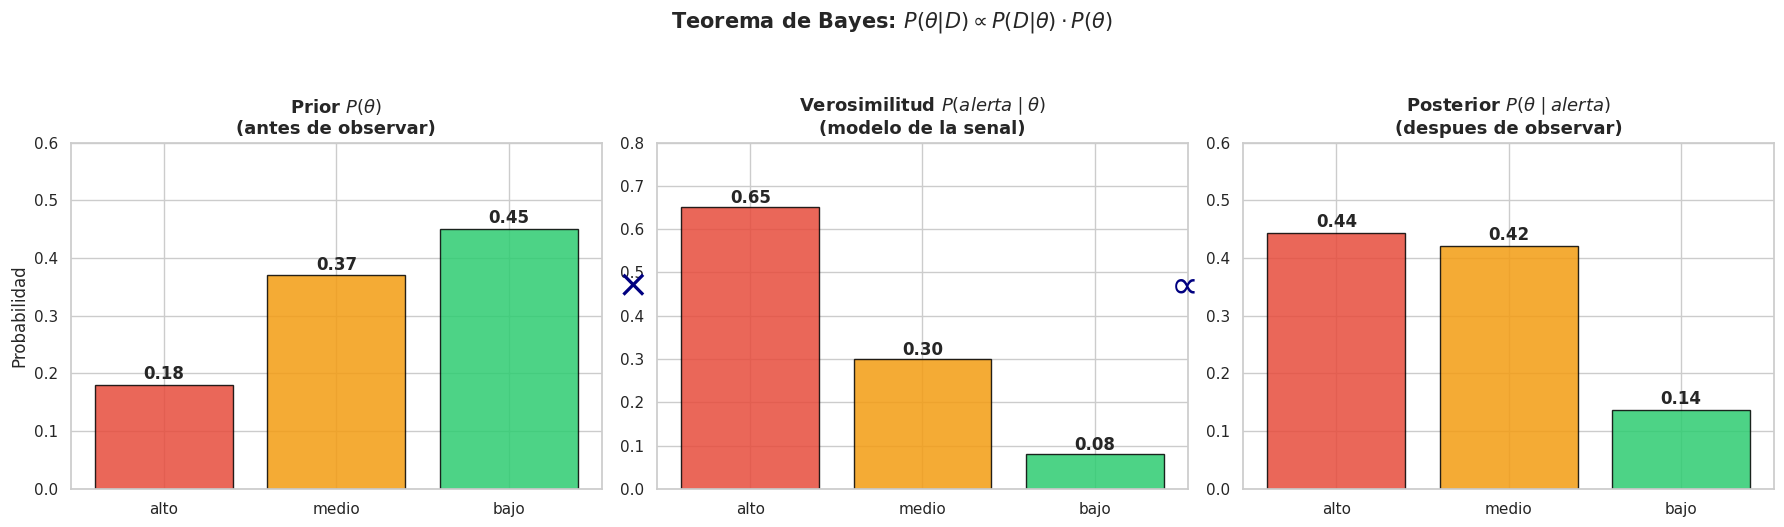


═══ Actualizacion Bayesiana Secuencial ═══
Observamos 3 alertas consecutivas. ¿Como evoluciona la creencia?

  Tras alerta #1: P(alto) = 0.4432, P(medio) = 0.4205, P(bajo) = 0.1364
  Tras alerta #2: P(alto) = 0.6776, P(medio) = 0.2967, P(bajo) = 0.0257
  Tras alerta #3: P(alto) = 0.8287, P(medio) = 0.1675, P(bajo) = 0.0039

  Tras 3 alertas, P(alto) paso de 0.18 a 0.8287
  → La evidencia acumulada concentra la creencia en el perfil correcto.


In [11]:
# --- Visualizacion: Actualizacion Bayesiana paso a paso ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
perfiles = ['alto', 'medio', 'bajo']
x_pos = np.arange(len(perfiles))
colors = ['#e74c3c', '#f39c12', '#2ecc71']

# Panel 1: Prior
ax = axes[0]
prior_vals = [prior[k] for k in perfiles]
bars = ax.bar(x_pos, prior_vals, color=colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, prior_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(perfiles)
ax.set_ylabel('Probabilidad')
ax.set_title('Prior $P(\\theta)$\n(antes de observar)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 0.6)

# Panel 2: Likelihood
ax2 = axes[1]
likelihood_vals = [p_alerta[k] for k in perfiles]
bars2 = ax2.bar(x_pos, likelihood_vals, color=colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars2, likelihood_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(perfiles)
ax2.set_title('Verosimilitud $P(alerta \\mid \\theta)$\n(modelo de la senal)', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 0.8)

# Panel 3: Posterior
ax3 = axes[2]
posterior_vals = [posterior_alerta[k] for k in perfiles]
bars3 = ax3.bar(x_pos, posterior_vals, color=colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars3, posterior_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(perfiles)
ax3.set_title('Posterior $P(\\theta \\mid alerta)$\n(despues de observar)', fontsize=13, fontweight='bold')
ax3.set_ylim(0, 0.6)

# Flechas entre paneles
fig.text(0.355, 0.5, '$\\times$', fontsize=28, ha='center', va='center', fontweight='bold', color='navy')
fig.text(0.66, 0.5, '$\\propto$', fontsize=28, ha='center', va='center', fontweight='bold', color='navy')

plt.suptitle('Teorema de Bayes: $P(\\theta | D) \\propto P(D | \\theta) \\cdot P(\\theta)$',
             fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# --- Actualizacion secuencial: multiples alertas ---
print("\n═══ Actualizacion Bayesiana Secuencial ═══")
print("Observamos 3 alertas consecutivas. ¿Como evoluciona la creencia?\n")

current_prior = prior.copy()
for obs_num in range(1, 4):
    p_total = sum(current_prior[k] * p_alerta[k] for k in current_prior)
    current_posterior = {k: current_prior[k] * p_alerta[k] / p_total for k in current_prior}
    print(f"  Tras alerta #{obs_num}: P(alto) = {current_posterior['alto']:.4f}, "
          f"P(medio) = {current_posterior['medio']:.4f}, P(bajo) = {current_posterior['bajo']:.4f}")
    current_prior = current_posterior

print(f"\n  Tras 3 alertas, P(alto) paso de {prior['alto']:.2f} a {current_posterior['alto']:.4f}")
print("  → La evidencia acumulada concentra la creencia en el perfil correcto.")

## 5. Variables aleatorias, distribuciones y funciones generadoras

### 5.1 Variables aleatorias como funciones medibles

Formalmente, una **variable aleatoria** es una funcion medible $X : (\Omega, \mathcal{F}) \to (\mathbb{R}, \mathcal{B}(\mathbb{R}))$. Es decir:

$$X^{-1}(B) = \{\omega \in \Omega : X(\omega) \in B\} \in \mathcal{F} \quad \forall B \in \mathcal{B}(\mathbb{R})$$

La **funcion de distribucion acumulada (CDF)** es $F_X(x) = P(X \leq x)$.

### 5.2 Caso discreto vs. continuo

| Propiedad | Discreta | Continua |
|-----------|----------|----------|
| Descripcion | PMF: $p(x) = P(X = x)$ | PDF: $f(x) = F'(x)$ |
| Esperanza | $E[X] = \sum_x x \, p(x)$ | $E[X] = \int_{-\infty}^{\infty} x \, f(x) \, dx$ |
| Varianza | $\text{Var}(X) = \sum_x (x - \mu)^2 p(x)$ | $\text{Var}(X) = \int (x - \mu)^2 f(x) \, dx$ |
| Normalizacion | $\sum_x p(x) = 1$ | $\int_{-\infty}^{\infty} f(x) \, dx = 1$ |

### 5.3 Funciones generadoras de momentos (MGF) y funcion caracteristica

La **MGF** de $X$ es $M_X(t) = E[e^{tX}]$ (cuando existe). Sus propiedades clave:

1. $M_X^{(n)}(0) = E[X^n]$ (genera todos los momentos)
2. Si $X$ e $Y$ son independientes, $M_{X+Y}(t) = M_X(t) M_Y(t)$
3. **Determina la distribucion** (si existe en un entorno de 0)

La **funcion caracteristica** $\varphi_X(t) = E[e^{itX}]$ siempre existe y es la herramienta fundamental para demostrar el TCL:

$$\varphi_{\bar{X}_n}(t) = \left[\varphi_X\left(\frac{t}{\sqrt{n}}\right)\right]^n \to e^{-t^2/2}$$

### 5.4 Distribuciones fundamentales y sus conexiones

Las distribuciones clasicas forman una red de relaciones (limites, transformaciones, conjugados):

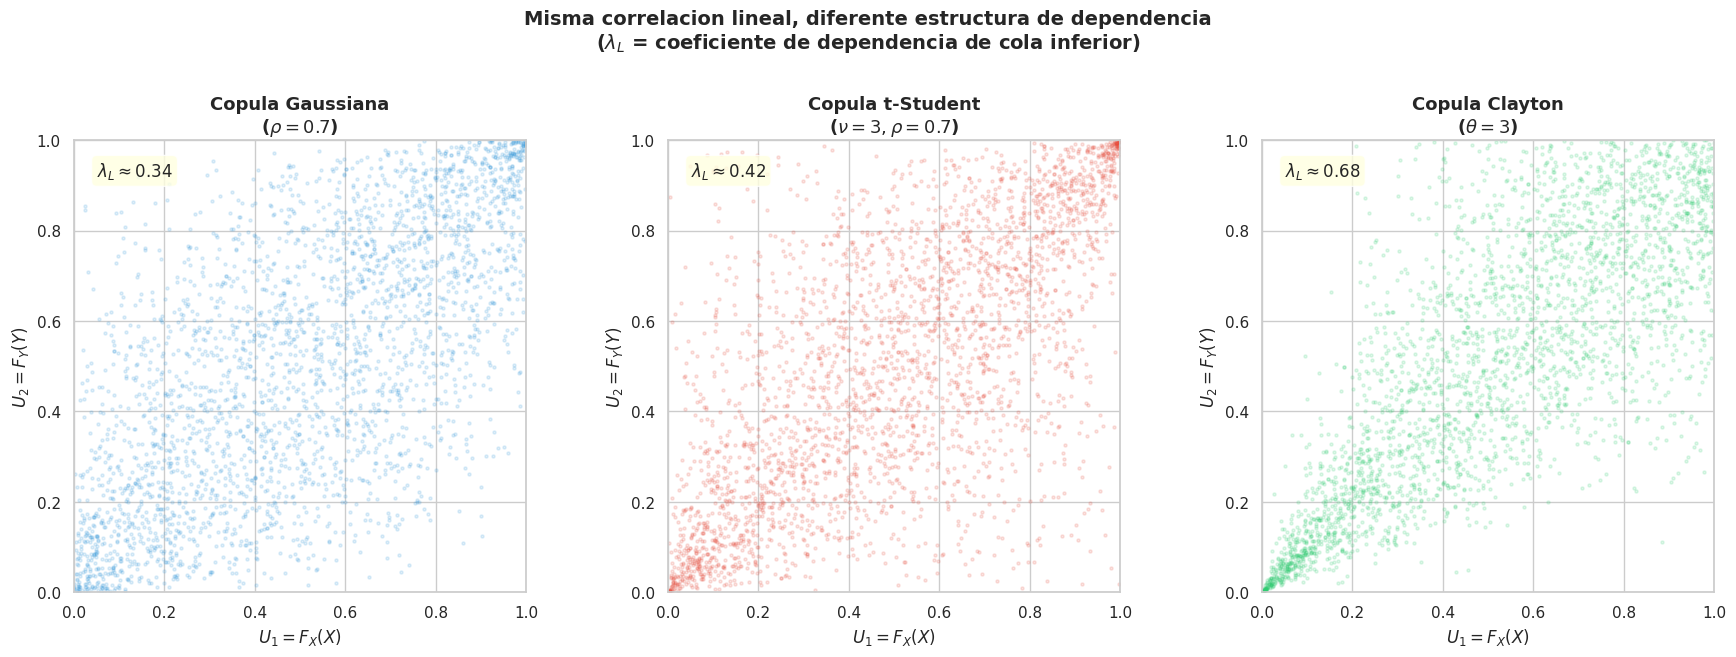

La copula Gaussiana tiene λ_L = 0 (sin dependencia de cola)
La copula t-Student con ν bajo tiene λ_L > 0 (crashes conjuntos)
La copula Clayton concentra la dependencia en la cola inferior

→ Tres modelos con la misma correlacion pero riesgo de cola muy diferente!


In [12]:
# --- Visualizacion: Copulas y dependencia de cola ---

np.random.seed(42)
n_cop = 3000

# Copula Gaussiana (rho = 0.7)
rho = 0.7
mean = [0, 0]
cov = [[1, rho], [rho, 1]]
z_gauss = np.random.multivariate_normal(mean, cov, n_cop)
u_gauss = stats.norm.cdf(z_gauss)

# Copula t-Student (nu=3, rho=0.7) — colas pesadas
nu = 3
z_t = np.random.multivariate_normal(mean, cov, n_cop)
chi2_samples = np.random.chisquare(nu, n_cop)
t_samples = z_t / np.sqrt(chi2_samples[:, None] / nu)
u_t = stats.t.cdf(t_samples, df=nu)

# Copula Clayton (theta = 3) — dependencia cola inferior
theta_clay = 3.0
u1_clay = np.random.uniform(0, 1, n_cop)
v = np.random.uniform(0, 1, n_cop)
u2_clay = (u1_clay**(-theta_clay) * (v**(-theta_clay/(1+theta_clay)) - 1) + 1)**(-1/theta_clay)
u2_clay = np.clip(u2_clay, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, u_data, titulo, color in [(axes[0], u_gauss, 'Copula Gaussiana\n($\\rho = 0.7$)', '#3498db'),
                                    (axes[1], np.column_stack([u_t[:,0], u_t[:,1]]), 'Copula t-Student\n($\\nu=3, \\rho=0.7$)', '#e74c3c'),
                                    (axes[2], np.column_stack([u1_clay, u2_clay]), 'Copula Clayton\n($\\theta = 3$)', '#2ecc71')]:
    ax.scatter(u_data[:, 0], u_data[:, 1], alpha=0.15, s=5, color=color)
    ax.set_xlabel('$U_1 = F_X(X)$', fontsize=12)
    ax.set_ylabel('$U_2 = F_Y(Y)$', fontsize=12)
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    
    # Calcular dependencia de cola inferior empirica
    q = 0.05
    tail_dep = np.mean((u_data[:, 0] < q) & (u_data[:, 1] < q)) / q
    ax.text(0.05, 0.92, f'$\\lambda_L \\approx {tail_dep:.2f}$', transform=ax.transAxes,
            fontsize=12, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Misma correlacion lineal, diferente estructura de dependencia\n'
             '($\\lambda_L$ = coeficiente de dependencia de cola inferior)',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("La copula Gaussiana tiene λ_L = 0 (sin dependencia de cola)")
print("La copula t-Student con ν bajo tiene λ_L > 0 (crashes conjuntos)")
print("La copula Clayton concentra la dependencia en la cola inferior")
print("\n→ Tres modelos con la misma correlacion pero riesgo de cola muy diferente!")

## 6. De Kolmogorov a la probabilidad moderna

### 6.1 Modos de convergencia

La axiomatica de 1933 abrio la puerta a estudiar **limites** de sucesiones de variables aleatorias. Hay varios modos de convergencia, con relaciones jerarquicas:

$$X_n \xrightarrow{L^p} X \implies X_n \xrightarrow{P} X \implies X_n \xrightarrow{d} X$$
$$X_n \xrightarrow{c.s.} X \implies X_n \xrightarrow{P} X$$

| Modo | Definicion | Intuicion |
|------|-----------|-----------|
| **Casi segura (c.s.)** | $P(\lim X_n = X) = 1$ | Para casi todo $\omega$, la trayectoria converge |
| **En probabilidad** | $P(\|X_n - X\| > \epsilon) \to 0$ | Desviaciones grandes se vuelven improbables |
| **En distribucion** | $F_{X_n}(x) \to F_X(x)$ en puntos de continuidad | Las CDFs convergen |
| **En $L^p$** | $E[\|X_n - X\|^p] \to 0$ | Los momentos convergen |

### 6.2 Ley de los grandes numeros (LGN)

**Ley debil (Khintchine):** Si $X_1, X_2, \ldots$ son i.i.d. con $E[X_i] = \mu$ y $\text{Var}(X_i) < \infty$:

$$\bar{X}_n = \frac{1}{n}\sum_{i=1}^n X_i \xrightarrow{P} \mu$$

**Ley fuerte (Kolmogorov):** Bajo las mismas condiciones:

$$\bar{X}_n \xrightarrow{c.s.} \mu$$

### 6.3 Teorema central del limite (TCL)

**Teorema (Lindeberg-Levy):** Si $X_1, X_2, \ldots$ son i.i.d. con $E[X_i] = \mu$ y $\text{Var}(X_i) = \sigma^2 < \infty$:

$$\frac{\sqrt{n}(\bar{X}_n - \mu)}{\sigma} \xrightarrow{d} \mathcal{N}(0, 1)$$

**Esquema de demostracion via funciones caracteristicas:**

Sea $Z_n = \frac{\sqrt{n}(\bar{X}_n - \mu)}{\sigma}$. Entonces:

$$\varphi_{Z_n}(t) = \left[\varphi_{(X-\mu)/\sigma}\left(\frac{t}{\sqrt{n}}\right)\right]^n$$

Expandiendo $\varphi_{(X-\mu)/\sigma}(s) = 1 - \frac{s^2}{2} + o(s^2)$ por Taylor:

$$\varphi_{Z_n}(t) = \left[1 - \frac{t^2}{2n} + o\left(\frac{1}{n}\right)\right]^n \to e^{-t^2/2} = \varphi_{\mathcal{N}(0,1)}(t) \quad \blacksquare$$

### 6.4 Filtraciones y martingalas

Una **filtracion** $\{\mathcal{F}_t\}_{t \geq 0}$ es una familia creciente de $\sigma$-algebras:

$$\mathcal{F}_s \subseteq \mathcal{F}_t \quad \text{para } s \leq t$$

Modela la **informacion disponible** hasta el tiempo $t$.

Un proceso adaptado $\{M_t\}$ es una **martingala** respecto a $\{\mathcal{F}_t\}$ si:

1. $E[|M_t|] < \infty$ para todo $t$
2. $E[M_t | \mathcal{F}_s] = M_s$ para todo $s \leq t$ (**juego justo**)

Variantes:
- **Submartingala:** $E[M_t | \mathcal{F}_s] \geq M_s$ (tendencia al alza)
- **Supermartingala:** $E[M_t | \mathcal{F}_s] \leq M_s$ (tendencia a la baja)

### 6.5 Teorema de parada opcional (Optional Stopping)

**Teorema (Doob):** Si $M_t$ es una martingala y $\tau$ es un tiempo de parada acotado, entonces:

$$E[M_\tau] = E[M_0]$$

**Aplicacion:** En el juego de la ruina del apostador, si apostamos \$1 en cada ronda con probabilidad 1/2 de ganar, el capital es una martingala. El teorema garantiza que $E[\text{capital al salir}] = \text{capital inicial}$.

## 4. Independencia: una hipotesis potente y peligrosa

Dos eventos $A$ y $B$ son independientes si

$$
P(A \cap B) = P(A) P(B).
$$

En muchos problemas reales la independencia es una aproximacion comoda, pero a veces falsa. Riesgo crediticio, mercados y clima suelen compartir choques comunes. Ignorar esa dependencia puede subestimar eventos extremos.


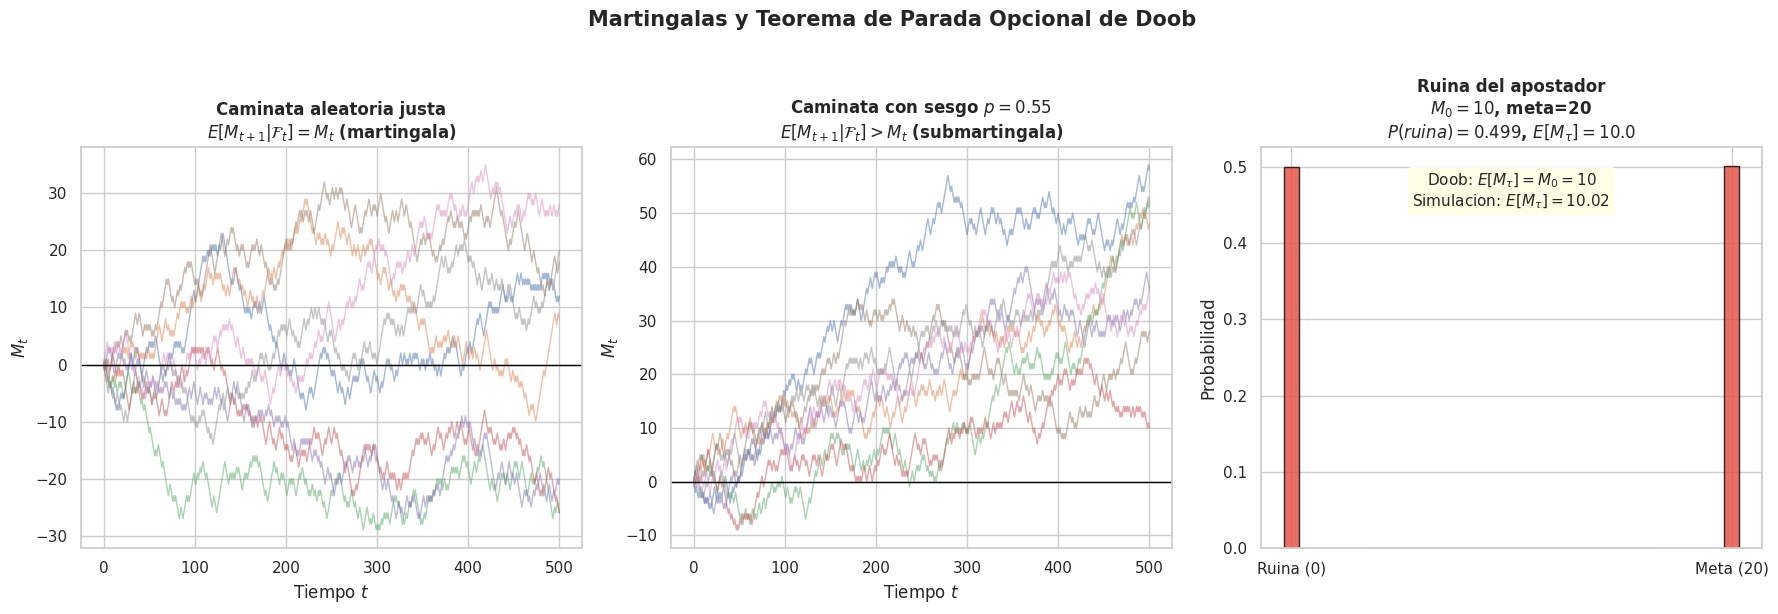

Ruina del apostador (capital=10, meta=20):
  Teoria: P(ruina) = 1 - 10/20 = 0.500
  Simulacion: P(ruina) = 0.499
  E[M_tau] teorico = 10, simulado = 10.02
  El teorema de parada se cumple: el juego justo no crea valor esperado.


In [16]:
# --- Martingalas: caminatas aleatorias, ruina del apostador, y Doob ---

np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Caminata aleatoria justa (martingala) vs sesgada (sub/supermartingala)
ax = axes[0]
T = 500
for trial in range(8):
    pasos = np.random.choice([-1, 1], size=T)
    martingala = np.concatenate([[0], np.cumsum(pasos)])
    ax.plot(martingala, alpha=0.5, linewidth=1)

ax.axhline(0, color='black', linewidth=1)
ax.set_title('Caminata aleatoria justa\n$E[M_{t+1} | \\mathcal{F}_t] = M_t$ (martingala)', fontsize=12, fontweight='bold')
ax.set_xlabel('Tiempo $t$')
ax.set_ylabel('$M_t$')

# Panel 2: Submartingala (sesgo positivo)
ax2 = axes[1]
for trial in range(8):
    pasos_sub = np.random.choice([-1, 1], size=T, p=[0.45, 0.55])
    submartingala = np.concatenate([[0], np.cumsum(pasos_sub)])
    ax2.plot(submartingala, alpha=0.5, linewidth=1)

ax2.axhline(0, color='black', linewidth=1)
ax2.set_title('Caminata con sesgo $p = 0.55$\n$E[M_{t+1} | \\mathcal{F}_t] > M_t$ (submartingala)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Tiempo $t$')
ax2.set_ylabel('$M_t$')

# Panel 3: Ruina del apostador - Teorema de parada opcional
ax3 = axes[2]
capital_inicial = 10
meta = 20
n_sims = 5000

tiempos_ruina = []
resultados = []

for sim in range(n_sims):
    capital = capital_inicial
    t_sim = 0
    while 0 < capital < meta and t_sim < 10000:
        capital += np.random.choice([-1, 1])
        t_sim += 1
    tiempos_ruina.append(t_sim)
    resultados.append(capital)

# E[M_tau] deberia = capital_inicial (si el juego es justo)
E_capital_final = np.mean(resultados)
p_ruina = np.mean(np.array(resultados) == 0)

ax3.hist(resultados, bins=[-0.5, 0.5, 19.5, 20.5], density=True, 
        #  color=[['#e74c3c', '#2ecc71']], 
        color=['#e74c3c'],
         edgecolor='black', alpha=0.8,
         rwidth=0.7)
ax3.set_xticks([0, 20])
ax3.set_xticklabels(['Ruina (0)', f'Meta ({meta})'])
ax3.set_ylabel('Probabilidad')
ax3.set_title(f'Ruina del apostador\n$M_0={capital_inicial}$, meta={meta}\n'
              f'$P(ruina) = {p_ruina:.3f}$, $E[M_\\tau] = {E_capital_final:.1f}$',
              fontsize=12, fontweight='bold')

# Verificar E[M_tau] = M_0
ax3.text(0.5, 0.85, f'Doob: $E[M_\\tau] = M_0 = {capital_inicial}$\n'
         f'Simulacion: $E[M_\\tau] = {E_capital_final:.2f}$',
         transform=ax3.transAxes, fontsize=11, ha='center',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Martingalas y Teorema de Parada Opcional de Doob', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Ruina del apostador (capital={capital_inicial}, meta={meta}):")
print(f"  Teoria: P(ruina) = 1 - {capital_inicial}/{meta} = {1-capital_inicial/meta:.3f}")
print(f"  Simulacion: P(ruina) = {p_ruina:.3f}")
print(f"  E[M_tau] teorico = {capital_inicial}, simulado = {E_capital_final:.2f}")
print(f"  El teorema de parada se cumple: el juego justo no crea valor esperado.")

In [17]:
n = 50_000

lluvia_ind = np.random.binomial(1, 0.12, size=n)
default_ind = np.random.binomial(1, 0.20, size=n)

p_inter_ind = np.mean((lluvia_ind == 1) & (default_ind == 1))
p_prod_ind = np.mean(lluvia_ind == 1) * np.mean(default_ind == 1)

choque = np.random.binomial(1, 0.10, size=n)
lluvia_dep = np.where(choque == 1, np.random.binomial(1, 0.55, size=n), np.random.binomial(1, 0.08, size=n))
default_dep = np.where(choque == 1, np.random.binomial(1, 0.45, size=n), np.random.binomial(1, 0.16, size=n))

p_inter_dep = np.mean((lluvia_dep == 1) & (default_dep == 1))
p_prod_dep = np.mean(lluvia_dep == 1) * np.mean(default_dep == 1)

comparacion = pd.DataFrame(
    {
        'modelo': ['independiente', 'dependiente por choque comun'],
        'P(A y B)': [p_inter_ind, p_inter_dep],
        'P(A)P(B)': [p_prod_ind, p_prod_dep],
        'brecha': [p_inter_ind - p_prod_ind, p_inter_dep - p_prod_dep],
    }
)

print(comparacion.round(4))


                         modelo  P(A y B)  P(A)P(B)  brecha
0                 independiente    0.0234    0.0235 -0.0001
1  dependiente por choque comun    0.0376    0.0242  0.0134


## 5. Variables aleatorias, esperanza y varianza

Una variable aleatoria es una funcion medible $X : \Omega \to \mathbb{R}$. En aplicaciones, $X$ puede representar:

- perdida de un portafolio
- numero de incumplimientos
- lluvia maxima anual
- retorno de una accion

Las dos metricas basicas son:

$$
E[X] = \sum_x x P(X = x), \qquad Var(X) = E[(X - E[X])^2].
$$

La esperanza resume el nivel promedio; la varianza resume dispersion y volatilidad.


             estado  perdida_musd  prob
0            normal             2  0.55
1  tension_liquidez             8  0.25
2          recesion            20  0.15
3  crisis_sistemica            45  0.05

E[Perdida] = 8.35 millones USD
Desviacion estandar = 10.48 millones USD
P(Perdida > 15) = 20.00%


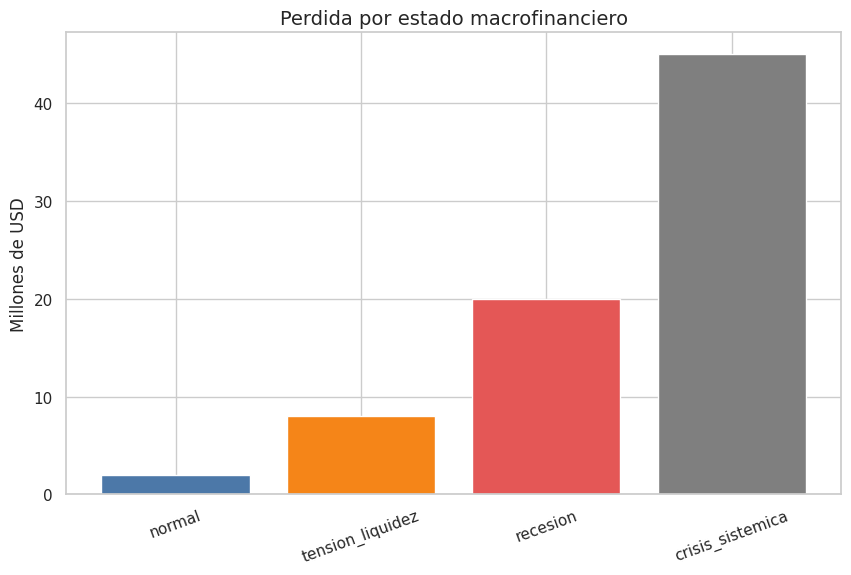

In [18]:
perdidas = pd.DataFrame(
    {
        'estado': ['normal', 'tension_liquidez', 'recesion', 'crisis_sistemica'],
        'perdida_musd': [2, 8, 20, 45],
        'prob': [0.55, 0.25, 0.15, 0.05],
    }
)

mu = float(np.dot(perdidas['perdida_musd'], perdidas['prob']))
var = float(np.dot((perdidas['perdida_musd'] - mu) ** 2, perdidas['prob']))
sigma = var ** 0.5
p_supera_15 = float(perdidas.loc[perdidas['perdida_musd'] > 15, 'prob'].sum())

print(perdidas)
print(f"\nE[Perdida] = {mu:.2f} millones USD")
print(f"Desviacion estandar = {sigma:.2f} millones USD")
print(f"P(Perdida > 15) = {p_supera_15:.2%}")

fig, ax = plt.subplots()
ax.bar(perdidas['estado'], perdidas['perdida_musd'], color=['#4c78a8', '#f58518', '#e45756', '#7f7f7f'])
ax.set_title('Perdida por estado macrofinanciero')
ax.set_ylabel('Millones de USD')
ax.tick_params(axis='x', rotation=20)
plt.show()


## 6. De Kolmogorov a la probabilidad moderna

La axiomatica de 1933 permitio extender la disciplina mucho mas alla de espacios finitos. La probabilidad moderna estudia medidas sobre espacios abstractos y procesos indexados en el tiempo.

Ideas clave:

- **Convergencia**: casi segura, en probabilidad, en distribucion, en $L^p$.
- **Ley de los grandes numeros**: promedios empiricos convergen al valor esperado.
- **Teorema central del limite**: sumas normalizadas se aproximan a una ley normal.
- **Filtraciones**: la informacion disponible hasta el tiempo $t$.
- **Martingalas**: procesos que modelan juego justo y son centrales en finanzas.
- **No estacionariedad**: en clima o macroeconomia, la medida de probabilidad puede cambiar con el tiempo.


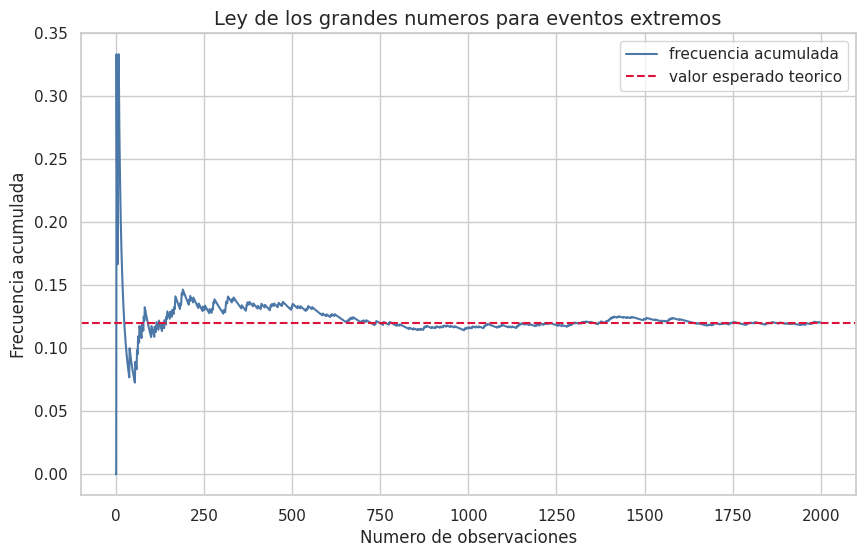

La frecuencia acumulada final es 0.1205 frente a p = 0.12.


In [19]:
p_extremo = 0.12
observaciones = np.random.binomial(1, p_extremo, size=2_000)
media_acumulada = np.cumsum(observaciones) / np.arange(1, len(observaciones) + 1)

fig, ax = plt.subplots()
ax.plot(media_acumulada, lw=1.5, color='#4c78a8', label='frecuencia acumulada')
ax.axhline(p_extremo, color='crimson', linestyle='--', label='valor esperado teorico')
ax.set_title('Ley de los grandes numeros para eventos extremos')
ax.set_xlabel('Numero de observaciones')
ax.set_ylabel('Frecuencia acumulada')
ax.legend()
plt.show()

print(f"La frecuencia acumulada final es {media_acumulada[-1]:.4f} frente a p = {p_extremo:.2f}.")


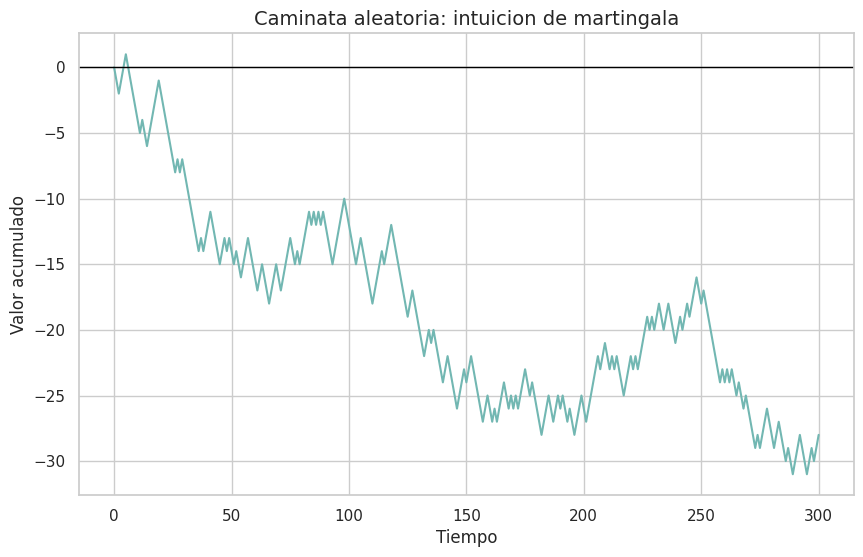

En una caminata justa, E[M_{t+1} | F_t] = M_t. Esa es la idea de martingala.


In [23]:
pasos = np.random.choice([-1, 1], size=300)
martingala = np.concatenate([[0], np.cumsum(pasos)])

fig, ax = plt.subplots()
ax.plot(martingala, color='#72b7b2')
ax.axhline(0, color='black', lw=1)
ax.set_title('Caminata aleatoria: intuicion de martingala')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Valor acumulado')
plt.show()

print('En una caminata justa, E[M_{t+1} | F_t] = M_t. Esa es la idea de martingala.')


## 10. Errores comunes, paradojas y conexiones profundas

### Errores comunes

| Error | Por que es peligroso | Correccion |
|-------|---------------------|-----------|
| Confundir $P(A \mid B)$ con $P(B \mid A)$ | "Falacia del fiscal": P(evidencia\|inocente) ≠ P(inocente\|evidencia) | Siempre aplicar Bayes explicitamente |
| Suponer independencia sin verificar | Subestima riesgo conjunto; causa raiz de la crisis 2008 | Modelar con copulas; buscar choques comunes |
| Resumir riesgo solo con media y varianza | No captura asimetria ni colas pesadas | Usar VaR, ES, y distribuciones de colas pesadas |
| Usar periodo de retorno estacionario en clima cambiante | Subestima frecuencia futura de extremos | GEV no estacionaria o analisis por ventanas |
| Extrapolar la Normal a las colas | La Normal subestima eventos extremos por definicion | Usar t-Student, Pareto, o GEV para colas |

### Paradojas clasicas

**Paradoja de Simpson:** Una tendencia que aparece en cada subgrupo puede **invertirse** al combinar los datos. Ocurre cuando hay una variable confusora no observada.

**Paradoja de San Petersburgo:** Un juego con $E[X] = \infty$ pero que nadie pagaria infinito por jugar. Resolucion: utilidad esperada (Bernoulli) o criterios de riesgo no lineales.

**Paradoja de Monty Hall:** Cambiar de puerta duplica la probabilidad de ganar. La intuicion falla porque no condicionamos correctamente sobre la informacion revelada.

### Conexiones con otras areas de la matematica

$$\boxed{\text{Probabilidad}} \xleftrightarrow{\text{Lebesgue}} \boxed{\text{Teoria de la Medida}} \xleftrightarrow{\text{Ito}} \boxed{\text{Calculo Estocastico}} \xleftrightarrow{\text{Black-Scholes}} \boxed{\text{Finanzas}}$$

$$\boxed{\text{Kolmogorov}} \xleftrightarrow{\text{ergodicidad}} \boxed{\text{Sistemas Dinamicos}} \xleftrightarrow{\text{entropia}} \boxed{\text{Teoria de la Informacion}}$$

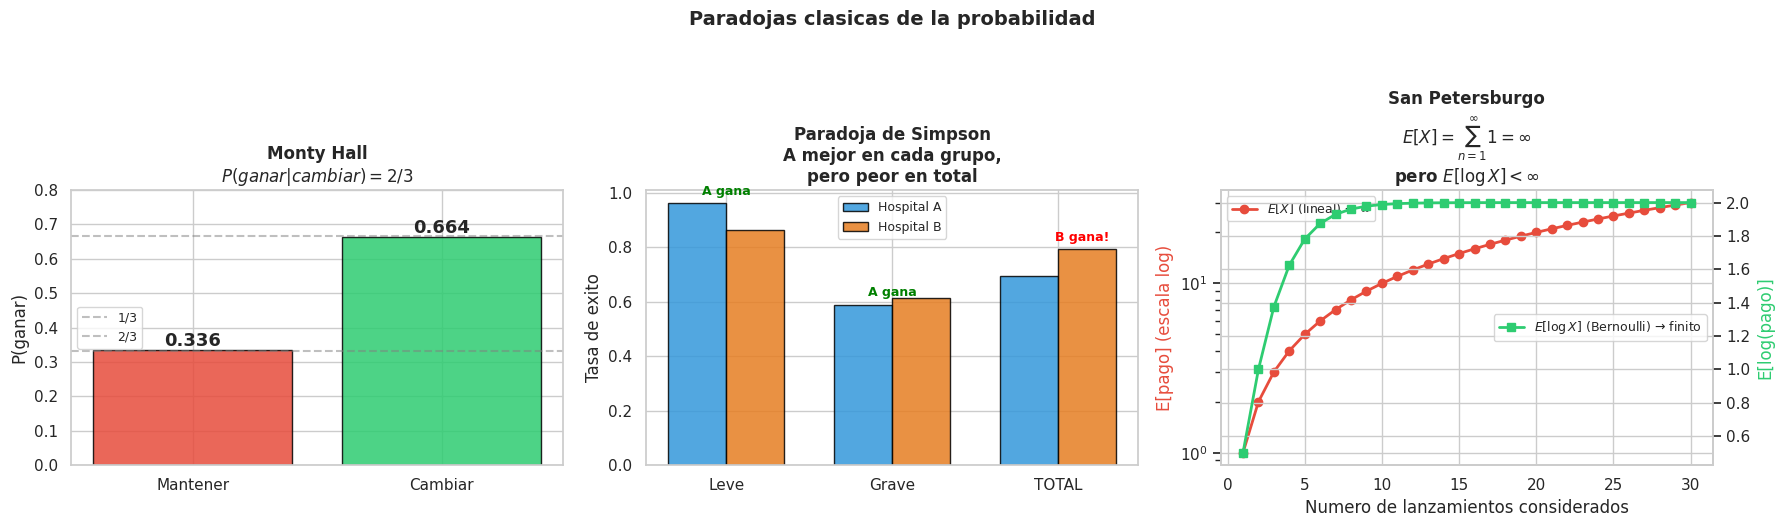

Lecciones:
  Monty Hall: condicionar correctamente sobre la informacion revelada
  Simpson: siempre verificar si hay variables confusoras antes de agregar
  San Petersburgo: la esperanza no siempre guia decisiones racionales → utilidad esperada


In [24]:
# --- Paradojas clasicas: simulacion ---

np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Paradoja de Monty Hall
n_monty = 50000
wins_stay = 0
wins_switch = 0

for _ in range(n_monty):
    prize = np.random.randint(3)
    choice = np.random.randint(3)
    # Host opens a door that is not the prize and not the choice
    available = [d for d in range(3) if d != choice and d != prize]
    host_opens = available[np.random.randint(len(available))]
    switch_to = [d for d in range(3) if d != choice and d != host_opens][0]
    
    if choice == prize:
        wins_stay += 1
    if switch_to == prize:
        wins_switch += 1

ax = axes[0]
bars = ax.bar(['Mantener', 'Cambiar'], [wins_stay/n_monty, wins_switch/n_monty],
              color=['#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.85)
ax.axhline(1/3, color='gray', linestyle='--', alpha=0.5, label='1/3')
ax.axhline(2/3, color='gray', linestyle='--', alpha=0.5, label='2/3')
for bar, val in zip(bars, [wins_stay/n_monty, wins_switch/n_monty]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=13, fontweight='bold')
ax.set_ylabel('P(ganar)')
ax.set_title('Monty Hall\n$P(ganar|cambiar) = 2/3$', fontsize=12, fontweight='bold')
ax.set_ylim(0, 0.8)
ax.legend(fontsize=9)

# 2. Paradoja de Simpson
ax2 = axes[1]
# Hospital A: trata mas casos graves
np.random.seed(42)
# Grupo leve
exito_A_leve = np.random.binomial(80, 0.95)   # 95% exito (n=80)
exito_B_leve = np.random.binomial(200, 0.90)   # 90% exito (n=200)
# Grupo grave
exito_A_grave = np.random.binomial(200, 0.60)  # 60% exito (n=200)
exito_B_grave = np.random.binomial(80, 0.55)    # 55% exito (n=80)

tasa_A_leve = exito_A_leve / 80
tasa_B_leve = exito_B_leve / 200
tasa_A_grave = exito_A_grave / 200
tasa_B_grave = exito_B_grave / 80
tasa_A_total = (exito_A_leve + exito_A_grave) / 280
tasa_B_total = (exito_B_leve + exito_B_grave) / 280

x_simp = np.arange(3)
width = 0.35
ax2.bar(x_simp - width/2, [tasa_A_leve, tasa_A_grave, tasa_A_total], width, 
        label='Hospital A', color='#3498db', edgecolor='black', alpha=0.85)
ax2.bar(x_simp + width/2, [tasa_B_leve, tasa_B_grave, tasa_B_total], width,
        label='Hospital B', color='#e67e22', edgecolor='black', alpha=0.85)
ax2.set_xticks(x_simp)
ax2.set_xticklabels(['Leve', 'Grave', 'TOTAL'])
ax2.set_ylabel('Tasa de exito')
ax2.set_title('Paradoja de Simpson\nA mejor en cada grupo,\npero peor en total', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)

# Anotaciones
ax2.annotate('A gana', xy=(0, tasa_A_leve), fontsize=9, color='green', fontweight='bold',
             xytext=(0, tasa_A_leve + 0.03), ha='center')
ax2.annotate('A gana', xy=(1, tasa_A_grave), fontsize=9, color='green', fontweight='bold',
             xytext=(1, tasa_A_grave + 0.03), ha='center')
ax2.annotate('B gana!', xy=(2, tasa_B_total), fontsize=9, color='red', fontweight='bold',
             xytext=(2.15, tasa_B_total + 0.03), ha='center')

# 3. San Petersburgo: utilidad logaritmica vs lineal
ax3 = axes[2]
n_flips = np.arange(1, 31)
pago = 2.0**n_flips
prob_n = 0.5**n_flips
E_lineal_acum = np.cumsum(pago * prob_n)
E_log_acum = np.cumsum(np.log2(pago) * prob_n)

ax3.semilogy(n_flips, E_lineal_acum, 'o-', color='#e74c3c', linewidth=2, label='$E[X]$ (lineal) → $\\infty$')
ax3_twin = ax3.twinx()
ax3_twin.plot(n_flips, E_log_acum, 's-', color='#2ecc71', linewidth=2, label='$E[\\log X]$ (Bernoulli) → finito')
ax3.set_xlabel('Numero de lanzamientos considerados')
ax3.set_ylabel('E[pago] (escala log)', color='#e74c3c')
ax3_twin.set_ylabel('E[log(pago)]', color='#2ecc71')
ax3.set_title('San Petersburgo\n$E[X] = \\sum_{n=1}^\\infty 1 = \\infty$\npero $E[\\log X] < \\infty$', 
              fontsize=12, fontweight='bold')
ax3.legend(loc='upper left', fontsize=9)
ax3_twin.legend(loc='center right', fontsize=9)

plt.suptitle('Paradojas clasicas de la probabilidad', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("Lecciones:")
print("  Monty Hall: condicionar correctamente sobre la informacion revelada")
print("  Simpson: siempre verificar si hay variables confusoras antes de agregar")
print("  San Petersburgo: la esperanza no siempre guia decisiones racionales → utilidad esperada")

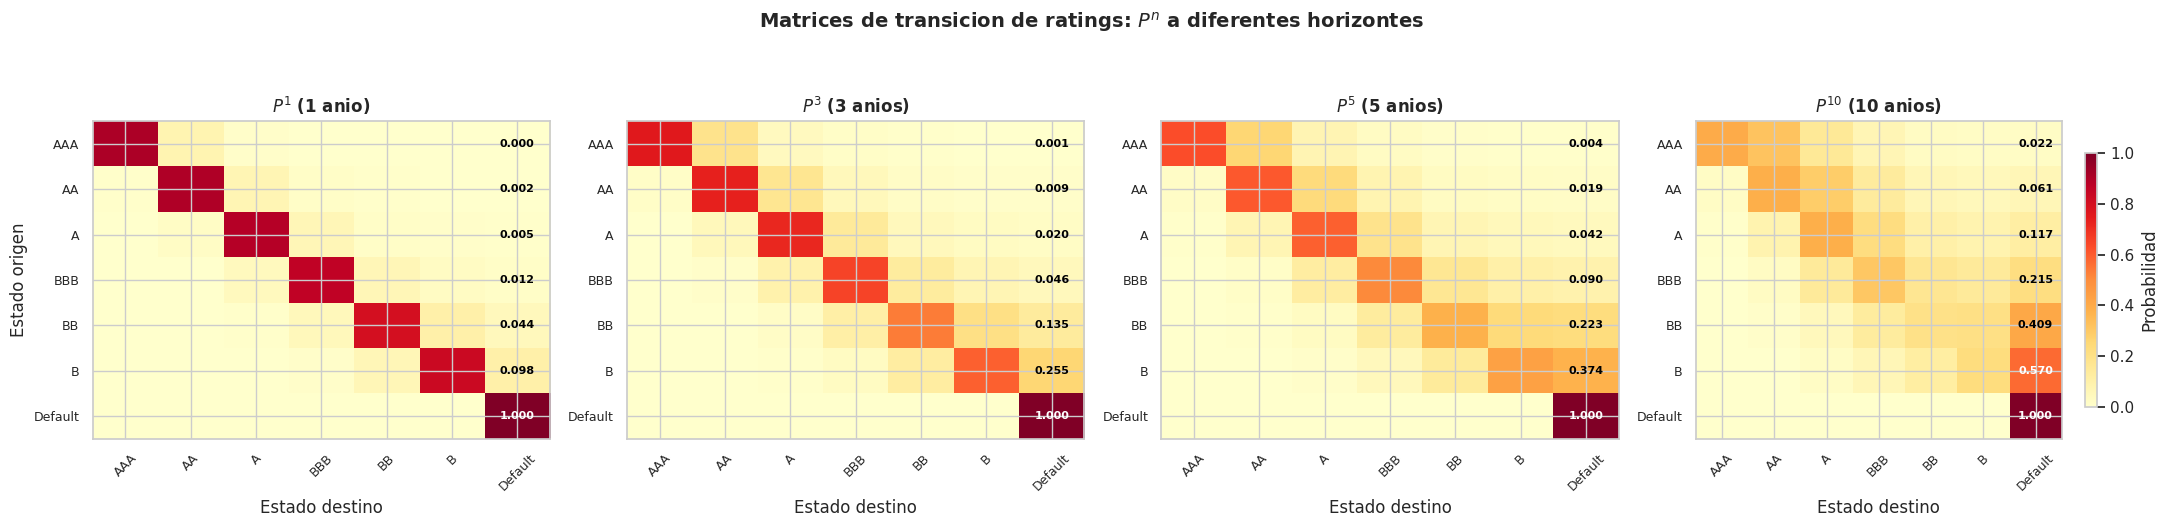


═══ Probabilidad acumulada de Default por rating y horizonte ═══

        1a      2a      3a      5a      7a     10a
AAA  0.000  0.0004  0.0012  0.0042  0.0095  0.0219
AA   0.002  0.0048  0.0086  0.0189  0.0332  0.0615
A    0.005  0.0118  0.0202  0.0418  0.0687  0.1169
BBB  0.012  0.0276  0.0462  0.0897  0.1384  0.2151
BB   0.044  0.0896  0.1354  0.2235  0.3041  0.4087
B    0.098  0.1821  0.2548  0.3736  0.4658  0.5699

Distribucion estacionaria π (largo plazo):
  π(AAA) = 0.0000
  π(AA) = 0.0000
  π(A) = 0.0000
  π(BBB) = 0.0000
  π(BB) = 0.0000
  π(B) = 0.0000
  π(Default) = 1.0000

Nota: Default es estado absorbente → π(Default) = 1 en el limite.
En la practica, se modela con nuevas emisiones para evitar la absorcion total.


In [25]:
# --- Cadenas de Markov: migracion de ratings crediticios ---

np.random.seed(42)

# Matriz de transicion anual estilizada (simplificada de S&P)
estados = ['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'Default']
n_est = len(estados)

P_trans = np.array([
    #  AAA    AA      A     BBB    BB     B    Def
    [0.910, 0.075, 0.010, 0.003, 0.001, 0.001, 0.000],  # AAA
    [0.005, 0.900, 0.070, 0.015, 0.005, 0.003, 0.002],  # AA
    [0.001, 0.020, 0.890, 0.060, 0.015, 0.009, 0.005],  # A
    [0.000, 0.003, 0.040, 0.860, 0.060, 0.025, 0.012],  # BBB
    [0.000, 0.001, 0.005, 0.050, 0.800, 0.100, 0.044],  # BB
    [0.000, 0.000, 0.002, 0.010, 0.060, 0.830, 0.098],  # B
    [0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 1.000],  # Default (absorbente)
])

# Verificar que cada fila suma 1
assert np.allclose(P_trans.sum(axis=1), 1.0), "Las filas deben sumar 1"

# Calcular matrices de transicion a 1, 3, 5 y 10 anios
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
horizontes = [1, 3, 5, 10]

for ax, h in zip(axes, horizontes):
    P_h = np.linalg.matrix_power(P_trans, h)
    im = ax.imshow(P_h, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(n_est))
    ax.set_yticks(range(n_est))
    ax.set_xticklabels(estados, fontsize=9, rotation=45)
    ax.set_yticklabels(estados, fontsize=9)
    ax.set_title(f'$P^{{{h}}}$ ({h} {"anio" if h==1 else "anios"})', fontsize=12, fontweight='bold')
    
    # Anotar probabilidades de default (ultima columna)
    for i in range(n_est):
        val = P_h[i, -1]
        color = 'white' if val > 0.5 else 'black'
        ax.text(n_est-1, i, f'{val:.3f}', ha='center', va='center', fontsize=8, 
                color=color, fontweight='bold')
    
    ax.set_xlabel('Estado destino')
    if h == 1:
        ax.set_ylabel('Estado origen')

plt.colorbar(im, ax=axes[-1], shrink=0.8, label='Probabilidad')
plt.suptitle('Matrices de transicion de ratings: $P^n$ a diferentes horizontes',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Tabla de probabilidades de default acumuladas
print("\n═══ Probabilidad acumulada de Default por rating y horizonte ═══\n")
pd_acum = {}
for h in [1, 2, 3, 5, 7, 10]:
    P_h = np.linalg.matrix_power(P_trans, h)
    pd_acum[f'{h}a'] = [P_h[i, -1] for i in range(n_est - 1)]

tabla_pd = pd.DataFrame(pd_acum, index=estados[:-1])
print(tabla_pd.round(4))

# Distribucion estacionaria (autovector izquierdo con autovalor 1)
eigenvalues, eigenvectors = np.linalg.eig(P_trans.T)
idx = np.argmin(np.abs(eigenvalues - 1.0))
pi_stat = np.real(eigenvectors[:, idx])
pi_stat = pi_stat / pi_stat.sum()

print(f"\nDistribucion estacionaria π (largo plazo):")
for s, p in zip(estados, pi_stat):
    print(f"  π({s}) = {p:.4f}")
print("\nNota: Default es estado absorbente → π(Default) = 1 en el limite.")
print("En la practica, se modela con nuevas emisiones para evitar la absorcion total.")

## 9.2 Aplicacion 5: Teoria de Valores Extremos (EVT) y distribuciones GEV

### El problema fundamental

En clima, hidrologia y finanzas, el interes no esta en el comportamiento "promedio" sino en los **extremos**: la inundacion del siglo, el crash bursatil, el terremoto maximo.

### Teorema de Fisher-Tippett-Gnedenko

Si $M_n = \max(X_1, \ldots, X_n)$ con $X_i$ i.i.d., y existen sucesiones $a_n > 0$, $b_n$ tales que:

$$\frac{M_n - b_n}{a_n} \xrightarrow{d} G$$

entonces $G$ pertenece a la familia **GEV (Generalized Extreme Value)**:

$$G(x; \mu, \sigma, \xi) = \exp\left\{-\left[1 + \xi\left(\frac{x - \mu}{\sigma}\right)\right]^{-1/\xi}\right\}$$

El parametro de forma $\xi$ determina el tipo de cola:

| $\xi$ | Tipo | Nombre | Colas | Ejemplos |
|-------|------|--------|-------|----------|
| $\xi = 0$ | I | Gumbel | Exponenciales | Temperaturas, vientos |
| $\xi > 0$ | II | Frechet | Pesadas (potencia) | Perdidas financieras, sismos |
| $\xi < 0$ | III | Weibull | Acotadas | Resistencia de materiales |

### Periodo de retorno no estacionario

Si la distribucion cambia con el tiempo (e.g., cambio climatico), el periodo de retorno $T(t)$ ya no es constante:

$$T(t) = \frac{1}{1 - G(x_0; \mu(t), \sigma(t), \xi)}$$

Un "evento de 100 anios" en 1950 puede ser un "evento de 20 anios" en 2025.

Ajuste GEV estacionario: ξ = 0.189, μ = 101.3, σ = 16.1
  Tipo: Frechet (colas pesadas)


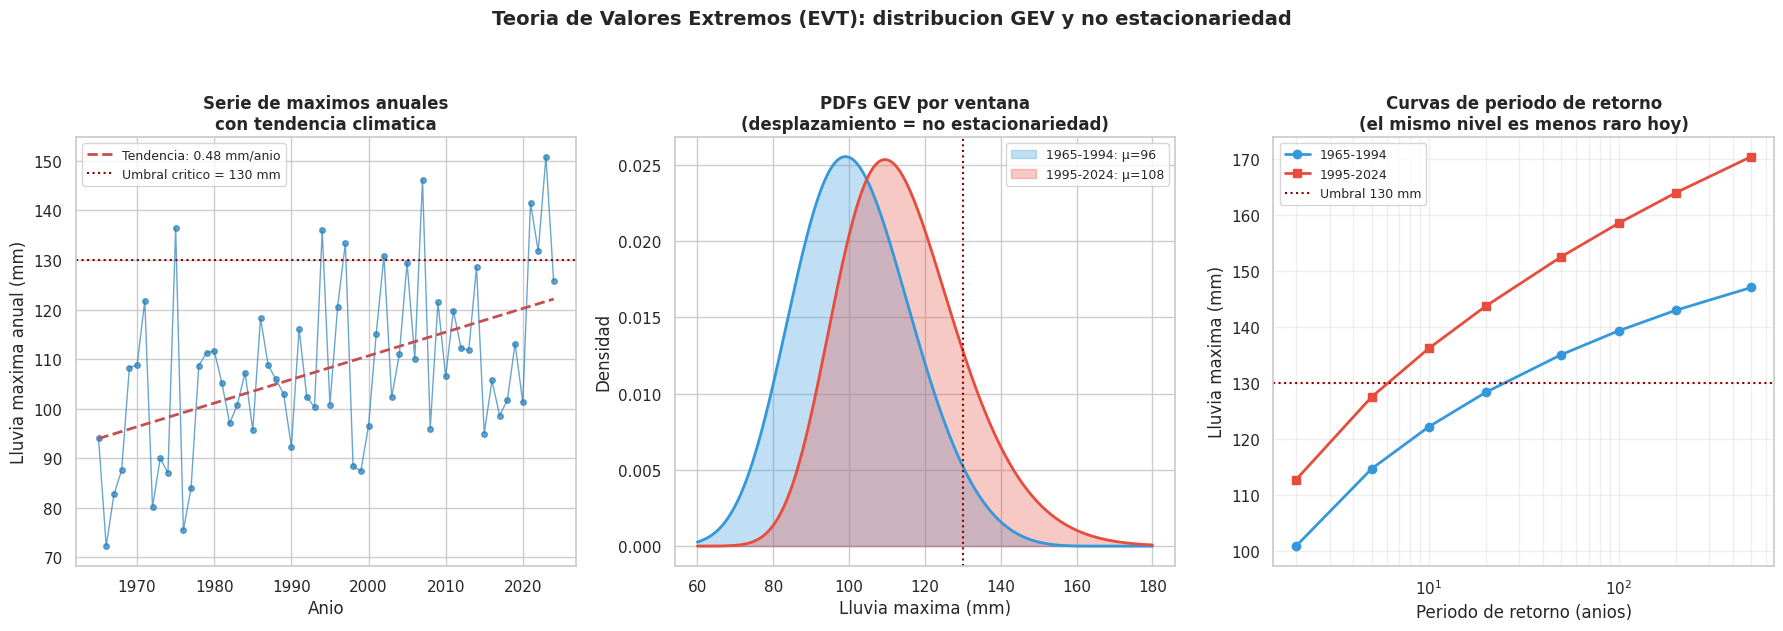


Periodo de retorno de 130 mm:
  Ventana 1965-1994: 25 anios
  Ventana 1995-2024: 6 anios
  → Lo que era un evento de ~25 anios ahora ocurre cada ~6 anios
     Esto invalida el uso de un solo 'periodo de retorno' sin considerar tendencia.


In [26]:
# --- Teoria de Valores Extremos: ajuste GEV a datos climaticos ---

np.random.seed(42)

# Generar datos sinteticos de lluvia maxima anual con tendencia
n_anios_gev = 60
anios_gev = np.arange(1965, 1965 + n_anios_gev)
tendencia = 0.5 * (anios_gev - 1965)  # tendencia lineal en la localizacion
lluvia_gev = tendencia + 85 + np.random.gumbel(loc=0, scale=12, size=n_anios_gev)

# Ajustar GEV estacionaria (todos los datos)
params_gev = stats.genextreme.fit(lluvia_gev)
xi_hat, mu_hat, sigma_hat = params_gev
print(f"Ajuste GEV estacionario: ξ = {xi_hat:.3f}, μ = {mu_hat:.1f}, σ = {sigma_hat:.1f}")
print(f"  Tipo: {'Frechet (colas pesadas)' if xi_hat > 0 else 'Weibull (acotada)' if xi_hat < 0 else 'Gumbel'}")

# Ajustar GEV a dos ventanas para mostrar no estacionariedad
ventana_1_gev = lluvia_gev[:30]
ventana_2_gev = lluvia_gev[30:]
params_1 = stats.genextreme.fit(ventana_1_gev)
params_2 = stats.genextreme.fit(ventana_2_gev)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Serie temporal con tendencia
ax = axes[0]
ax.plot(anios_gev, lluvia_gev, 'o-', color='#2980b9', markersize=4, linewidth=1, alpha=0.7)
# Regresion lineal
z_trend = np.polyfit(anios_gev, lluvia_gev, 1)
ax.plot(anios_gev, np.polyval(z_trend, anios_gev), 'r--', linewidth=2, 
        label=f'Tendencia: {z_trend[0]:.2f} mm/anio')
ax.axhline(130, color='darkred', linestyle=':', linewidth=1.5, label='Umbral critico = 130 mm')
ax.set_xlabel('Anio')
ax.set_ylabel('Lluvia maxima anual (mm)')
ax.set_title('Serie de maximos anuales\ncon tendencia climatica', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# Panel 2: Comparacion de PDFs GEV por ventana
ax2 = axes[1]
x_gev = np.linspace(60, 180, 300)

pdf_1 = stats.genextreme.pdf(x_gev, *params_1)
pdf_2 = stats.genextreme.pdf(x_gev, *params_2)

ax2.fill_between(x_gev, pdf_1, alpha=0.3, color='#3498db', label=f'1965-1994: μ={params_1[1]:.0f}')
ax2.plot(x_gev, pdf_1, color='#3498db', linewidth=2)
ax2.fill_between(x_gev, pdf_2, alpha=0.3, color='#e74c3c', label=f'1995-2024: μ={params_2[1]:.0f}')
ax2.plot(x_gev, pdf_2, color='#e74c3c', linewidth=2)
ax2.axvline(130, color='darkred', linestyle=':', linewidth=1.5)
ax2.set_xlabel('Lluvia maxima (mm)')
ax2.set_ylabel('Densidad')
ax2.set_title('PDFs GEV por ventana\n(desplazamiento = no estacionariedad)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)

# Panel 3: Periodo de retorno
ax3 = axes[2]
rp_levels = np.array([2, 5, 10, 20, 50, 100, 200, 500])
quantiles_1 = stats.genextreme.isf(1/rp_levels, *params_1)
quantiles_2 = stats.genextreme.isf(1/rp_levels, *params_2)

ax3.semilogx(rp_levels, quantiles_1, 'o-', color='#3498db', linewidth=2, markersize=6, label='1965-1994')
ax3.semilogx(rp_levels, quantiles_2, 's-', color='#e74c3c', linewidth=2, markersize=6, label='1995-2024')
ax3.axhline(130, color='darkred', linestyle=':', linewidth=1.5, label='Umbral 130 mm')
ax3.set_xlabel('Periodo de retorno (anios)')
ax3.set_ylabel('Lluvia maxima (mm)')
ax3.set_title('Curvas de periodo de retorno\n(el mismo nivel es menos raro hoy)', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, which='both', alpha=0.3)

plt.suptitle('Teoria de Valores Extremos (EVT): distribucion GEV y no estacionariedad',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Calcular periodos de retorno del umbral 130 mm en ambas ventanas
rp_1 = 1 / stats.genextreme.sf(130, *params_1)
rp_2 = 1 / stats.genextreme.sf(130, *params_2)
print(f"\nPeriodo de retorno de 130 mm:")
print(f"  Ventana 1965-1994: {rp_1:.0f} anios")
print(f"  Ventana 1995-2024: {rp_2:.0f} anios")
print(f"  → Lo que era un evento de ~{rp_1:.0f} anios ahora ocurre cada ~{rp_2:.0f} anios")
print(f"     Esto invalida el uso de un solo 'periodo de retorno' sin considerar tendencia.")

## 7. Aplicacion 1: analisis de perfil de riesgo

Un uso natural de Bayes en riesgo es actualizar la probabilidad de incumplimiento cuando observamos alertas operativas o financieras.

Aqui partimos de un perfil base y calculamos la **perdida esperada**

$$
EL = PD \times LGD \times EAD,
$$

donde:

- $PD$: probabilidad de default
- $LGD$: perdida dado default
- $EAD$: exposicion al momento del default


In [27]:
portafolio = pd.DataFrame(
    {
        'cliente': ['Andes SAC', 'Costa Retail', 'Sierra Agro', 'Delta Logistica'],
        'perfil': ['alto', 'medio', 'bajo', 'medio'],
        'EAD': [1_200_000, 850_000, 600_000, 1_500_000],
        'LGD': [0.55, 0.40, 0.30, 0.45],
        'alerta_temprana': [1, 1, 0, 0],
    }
)

portafolio['PD_prior'] = portafolio['perfil'].map(prior)
portafolio['PD_ajustada'] = np.where(
    portafolio['alerta_temprana'] == 1,
    portafolio['perfil'].map(posterior_alerta),
    portafolio['perfil'].map(posterior_sin_alerta),
)
portafolio['EL_prior'] = portafolio['PD_prior'] * portafolio['LGD'] * portafolio['EAD']
portafolio['EL_ajustada'] = portafolio['PD_ajustada'] * portafolio['LGD'] * portafolio['EAD']
portafolio['incremento_EL'] = portafolio['EL_ajustada'] - portafolio['EL_prior']

prioridades = portafolio.sort_values('EL_ajustada', ascending=False)
print(prioridades[['cliente', 'perfil', 'alerta_temprana', 'PD_ajustada', 'EL_ajustada', 'incremento_EL']].round(2))


           cliente perfil  alerta_temprana  PD_ajustada  EL_ajustada  \
0        Andes SAC   alto                1         0.44    292500.00   
3  Delta Logistica  medio                0         0.35    237533.97   
1     Costa Retail  medio                1         0.42    142954.55   
2      Sierra Agro   bajo                0         0.56    101250.00   

   incremento_EL  
0      173700.00  
3      -12216.03  
1       17154.55  
2       20250.00  


## 8. Aplicacion 2: finanzas y riesgo de cola

En finanzas no basta con mirar esperanza y varianza. Tambien importan las colas de la distribucion. Dos medidas clasicas son:

- **VaR al nivel $\alpha$**: cuantil de la perdida.
- **Expected Shortfall (ES)**: perdida promedio condicionada a estar en la cola mas severa.

En entornos de mercado con cambios de regimen, la mezcla de distribuciones captura mejor el riesgo extremo que un solo escenario normal.


VaR 95% = USD 199,378
ES 95% = USD 385,313
P(perder mas de USD 150,000 en el mes) = 6.07%


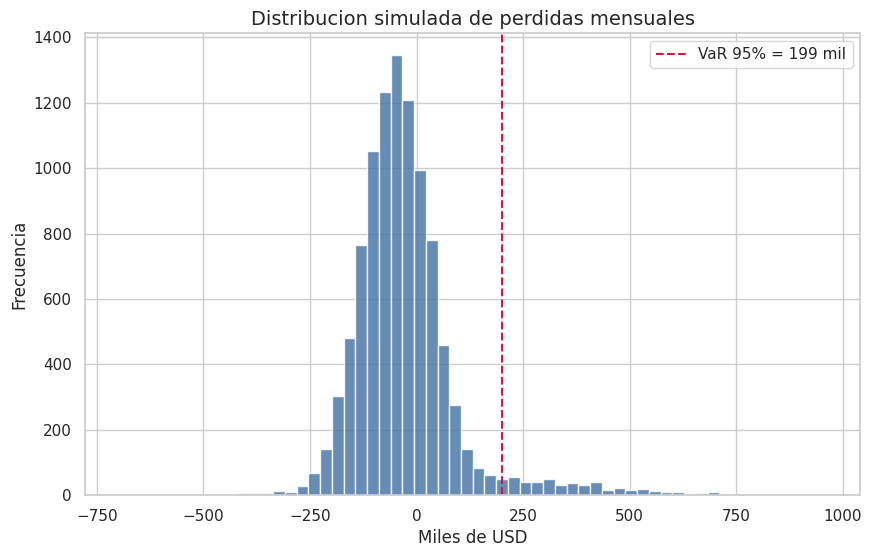

In [28]:
n_sim = 10_000
valor_portafolio = 5_000_000
estres = np.random.binomial(1, 0.12, size=n_sim)
retornos = np.where(
    estres == 1,
    np.random.normal(-0.03, 0.05, size=n_sim),
    np.random.normal(0.01, 0.015, size=n_sim),
)
perdidas_mensuales = -valor_portafolio * retornos

var_95 = float(np.quantile(perdidas_mensuales, 0.95))
es_95 = float(perdidas_mensuales[perdidas_mensuales >= var_95].mean())
prob_perder_150k = float(np.mean(perdidas_mensuales > 150_000))

print(f"VaR 95% = USD {var_95:,.0f}")
print(f"ES 95% = USD {es_95:,.0f}")
print(f"P(perder mas de USD 150,000 en el mes) = {prob_perder_150k:.2%}")

fig, ax = plt.subplots()
ax.hist(perdidas_mensuales / 1_000, bins=60, color='#4c78a8', alpha=0.85)
ax.axvline(var_95 / 1_000, color='crimson', linestyle='--', label=f'VaR 95% = {var_95/1000:,.0f} mil')
ax.set_title('Distribucion simulada de perdidas mensuales')
ax.set_xlabel('Miles de USD')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.show()


## 9. Aplicacion 3: clima, excedencias y no estacionariedad

En clima, el interes suele estar en probabilidades de excedencia: por ejemplo, la probabilidad de que la lluvia maxima anual supere un umbral critico.

Un punto moderno importante: si el clima cambia, la distribucion tambien cambia. En ese caso hablar de un unico "periodo de retorno" puede ser enganoso; conviene comparar ventanas temporales o modelar una probabilidad dependiente del tiempo.


## Cierre y mapa de la probabilidad moderna

### Lo que cubrimos

Esta notebook recorre un arco desde los **axiomas de Kolmogorov (1933)** hasta herramientas del siglo XXI en machine learning probabilistico:

| Nivel | Temas | Herramientas |
|-------|-------|-------------|
| **Fundamentos** | Espacio de probabilidad, axiomas | Conjuntos, medida |
| **Reglas** | Complemento, union, inclusion-exclusion | Combinatoria |
| **Condicional** | Bayes, ley total, actualizacion secuencial | Inferencia |
| **Dependencia** | Independencia, copulas, dependencia de cola | Modelado conjunto |
| **Variables** | CDF, PDF, MGF, funcion caracteristica | Distribucion |
| **Limites** | LGN, TCL, modos de convergencia | Asintotica |
| **Procesos** | Martingalas, Markov, filtraciones | Dinamica temporal |
| **Extremos** | GEV, periodos de retorno | Riesgo de cola |
| **BNNs** | MC Dropout, Deep Ensembles, incertidumbre | Deep Learning Bayesiano |
| **VAEs** | ELBO, reparametrizacion, posterior collapse | Modelos generativos latentes |
| **Flows** | RealNVP, cambio de variable, densidad exacta | Normalizing Flows |
| **Difusion** | DDPM, Score-SDE, proceso reverso | Modelos generativos |
| **Conformal** | Split CP, CQR, ACI, cobertura garantizada | Cuantificacion de incertidumbre |

### Conexion: de Kolmogorov al deep learning probabilistico

La axiomatica de Kolmogorov no es solo historia - es el **lenguaje** de todo lo que sigue:

- **BNNs** definen distribuciones posteriores $p(\theta \mid \mathcal{D})$ sobre pesos, usando regla de Bayes (S3)
- **VAEs** maximizan una cota inferior de la log-verosimilitud marginal $\log p(x)$ - teoria de la medida
- **Normalizing Flows** aplican cambio de variable con jacobianos - analisis multivariante probabilistico
- **DDPM** definen cadenas de Markov (S6) de difusion y reverso
- **Prediccion conformal** usa intercambiabilidad - extension del concepto de independencia (S4)

### Referencias de las secciones avanzadas

16. Lakshminarayanan, Pritzel & Blundell (2017). *Simple and Scalable Predictive Uncertainty Estimation using Deep Ensembles*. arXiv:1612.01474
17. Ovadia et al. (2019). *Can You Trust Your Model's Uncertainty?* arXiv:1906.02530
18. Fort, Hu & Lakshminarayanan (2019). *Deep Ensembles: A Loss Landscape Perspective*. arXiv:1912.02757
19. Papamarkou et al. (2024). *Position: Bayesian Deep Learning is Needed in the Age of Large-Scale AI*. arXiv:2309.16314
20. Sharma et al. (2025). *Fundamental Trade-offs in Bayesian Neural Networks*. arXiv:2503.11808
21. Kingma & Welling (2019). *An Introduction to Variational Autoencoders*. arXiv:1906.02691
22. Zhao, Song & Ermon (2019). *InfoVAE: Balancing Learning and Inference*. arXiv:1706.02262
23. Chen et al. (2018). *Isolating Sources of Disentanglement in VAEs*. arXiv:1802.04942
24. Rezende & Mohamed (2015). *Variational Inference with Normalizing Flows*. arXiv:1505.05770
25. Dinh, Sohl-Dickstein & Bengio (2017). *Density Estimation Using Real-valued Non-Volume Preserving Transformations*. arXiv:1605.08803
26. Kingma & Dhariwal (2018). *Glow: Generative Flow with Invertible 1x1 Convolutions*. arXiv:1807.03039
27. Grathwohl et al. (2018). *FFJORD: Free-form Continuous Dynamics for Scalable Reversible Generative Models*. arXiv:1810.01367
28. Ho, Jain & Abbeel (2020). *Denoising Diffusion Probabilistic Models*. arXiv:2006.11239
29. Song et al. (2021). *Score-Based Generative Modeling through Stochastic Differential Equations*. arXiv:2011.13456
30. Song, Meng & Ermon (2020). *Denoising Diffusion Implicit Models*. arXiv:2010.02502
31. Lipman et al. (2023). *Flow Matching for Generative Modeling*. arXiv:2210.02747
32. Song et al. (2023). *Consistency Models*. arXiv:2303.01469
33. Angelopoulos & Bates (2021). *A Gentle Introduction to Conformal Prediction*. arXiv:2107.07511
34. Romano, Patterson & Candes (2019). *Conformalized Quantile Regression*. arXiv:1905.03222
35. Angelopoulos, Bates et al. (2021). *Learn then Test*. arXiv:2110.01052
36. Zaffran et al. (2022). *Adaptive Conformal Predictions for Time Series*. arXiv:2010.09107

## 10. Deep Learning Bayesiano: BNNs, MC Dropout y Deep Ensembles

### 10.1 De Kolmogorov al aprendizaje profundo probabilistico

La teoria axiomatica de Kolmogorov proporciona el lenguaje riguroso para cuantificar incertidumbre en redes neuronales. En lugar de estimar pesos puntuales $\hat{\theta}$, una **red neuronal bayesiana (BNN)** define una distribucion posterior sobre los pesos:

$$p(\theta \mid \mathcal{D}) = \frac{p(\mathcal{D} \mid \theta)\, p(\theta)}{p(\mathcal{D})} = \frac{p(\mathcal{D} \mid \theta)\, p(\theta)}{\int p(\mathcal{D} \mid \theta')\, p(\theta')\, d\theta'}$$

La integral del denominador es intratable para redes con millones de parametros, lo que motiva metodos aproximados.

### 10.2 Tipos de incertidumbre

| Tipo | Fuente | Reducible con mas datos | Ejemplo |
|------|--------|------------------------|----------|
| **Aleatotica** (datos) | Ruido inherente en $y \mid x$ | No | Volatilidad intrinseca del mercado |
| **Epistemica** (modelo) | Conocimiento limitado de $\theta$ | Si | Prediccion fuera de distribucion |

La descomposicion de la varianza predictiva total es:

$$\text{Var}[y \mid x, \mathcal{D}] = \underbrace{\mathbb{E}_\theta[\text{Var}[y \mid x, \theta]]}_{\text{aleatotica}} + \underbrace{\text{Var}_\theta[\mathbb{E}[y \mid x, \theta]]}_{\text{epistemica}}$$

### 10.3 Inferencia variacional y el ELBO

Dado que $p(\theta \mid \mathcal{D})$ es intratable, aproximamos con $q_\phi(\theta)$ minimizando la divergencia KL:

$$\text{KL}[q_\phi(\theta) \| p(\theta \mid \mathcal{D})] = \log p(\mathcal{D}) - \mathcal{L}(\phi)$$

donde el **Evidence Lower Bound (ELBO)** es:

$$\mathcal{L}(\phi) = \mathbb{E}_{q_\phi}[\log p(\mathcal{D} \mid \theta)] - \text{KL}[q_\phi(\theta) \| p(\theta)]$$

Maximizar el ELBO equivale a minimizar la KL, y balancea ajuste a datos vs regularizacion hacia la prior.

### 10.4 MC Dropout como inferencia variacional

**Gal & Ghahramani (2016)** demostraron que dropout en test time aproxima inferencia variacional con una distribucion $q_\phi$ tipo Bernoulli sobre los pesos. Esto convierte cualquier red con dropout en una BNN aproximada:

$$p(y \mid x, \mathcal{D}) \approx \frac{1}{T}\sum_{t=1}^{T} p(y \mid x, \hat{\theta} \odot m_t), \quad m_t \sim \text{Bernoulli}(1-p)$$

### 10.5 Deep Ensembles (Lakshminarayanan et al., 2017)

**Deep Ensembles** (arXiv:1612.01474) entrenan $M$ redes con inicializaciones distintas. Cada miembro predice media $\mu_m(x)$ y varianza $\sigma^2_m(x)$ (incertidumbre aleatotica). La incertidumbre total se descompone:

$$\text{Var}_{\text{total}} = \underbrace{\frac{1}{M}\sum_m \sigma^2_m(x)}_{\text{aleatotica}} + \underbrace{\frac{1}{M}\sum_m (\mu_m(x) - \bar{\mu}(x))^2}_{\text{epistemica}}$$

Ovadia et al. (2019, arXiv:1906.02530) mostraron que deep ensembles superan consistentemente a otras tecnicas de incertidumbre bajo dataset shift.

### 10.6 Investigacion reciente

- **Fort et al. (2019, arXiv:1912.02757):** Deep ensembles exploran modos diversos del paisaje de perdida, explicando su superioridad sobre MC Dropout.
- **Papamarkou et al. (2024, arXiv:2309.16314):** Revision comprensiva de BNNs con guias para priors, diagnosticos y escalabilidad.
- **Sharma et al. (2025, arXiv:2503.11808):** Trade-offs fundamentales entre calibracion, separabilidad OOD y sharpness en BNNs.

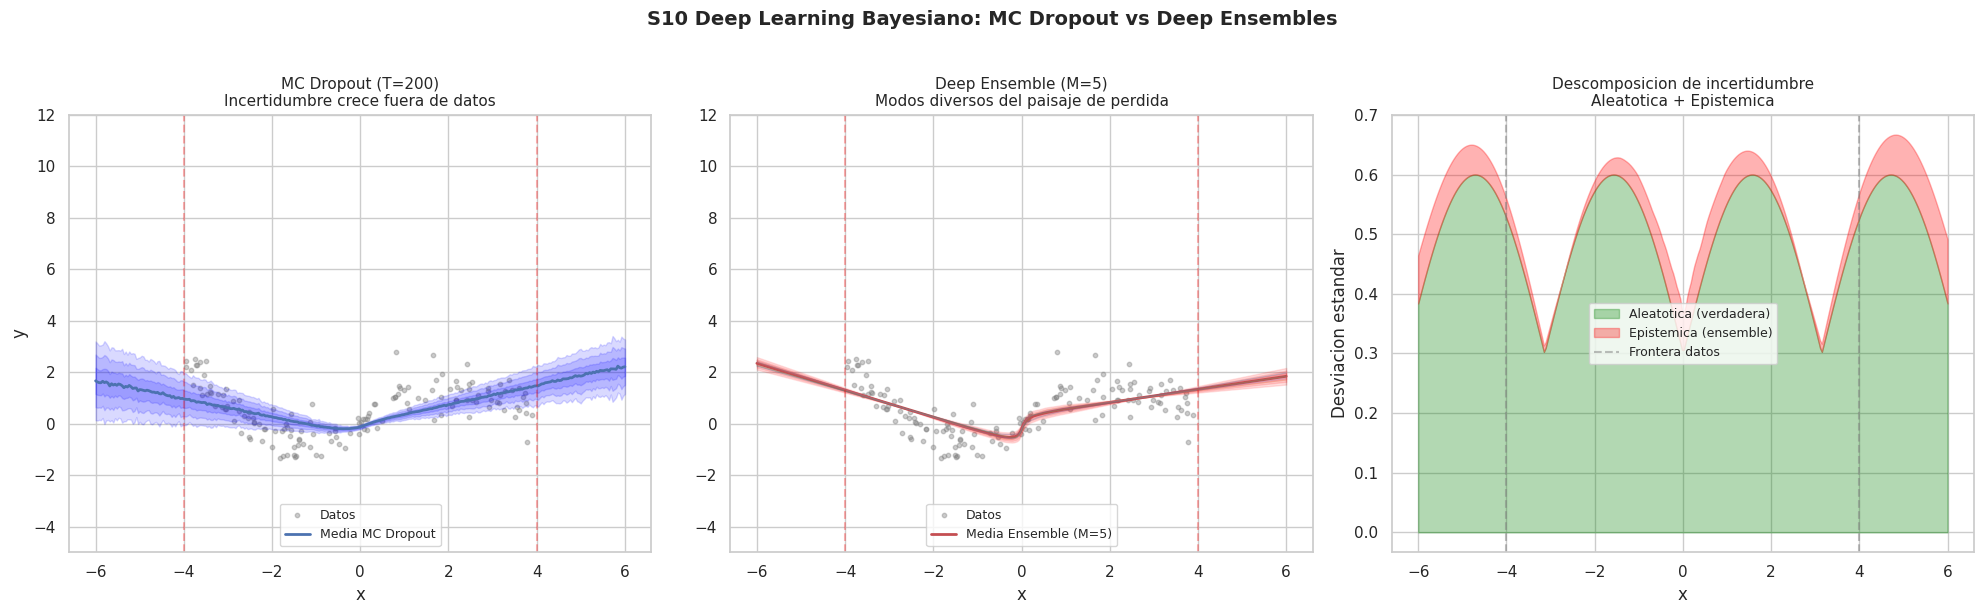

METRICAS DE CALIBRACION
  MC Dropout: cobertura 1s = 16.00% (esperado ~ 68.27%)
  MC Dropout: cobertura 2s = 30.67% (esperado ~ 95.45%)

  Ensemble: cobertura 1s = 4.00% (esperado ~ 68.27%)
  Ensemble: cobertura 2s = 8.00% (esperado ~ 95.45%)



In [29]:
# --- Deep Learning Bayesiano: MC Dropout vs Deep Ensembles ---
np.random.seed(42)

# Datos sinteticos: regresion no lineal con ruido heteroscedastico
n_train = 150
x_train = np.sort(np.random.uniform(-4, 4, n_train))
noise_std = 0.3 + 0.3 * np.abs(np.sin(x_train))
y_train = np.sin(x_train) + 0.1 * x_train**2 + noise_std * np.random.randn(n_train)

x_test = np.linspace(-6, 6, 300)

# --- BNN con MC Dropout (implementacion manual) ---
class SimpleBNN:
    """Red neuronal 2 capas con dropout como inferencia variacional aproximada."""
    def __init__(self, hidden=50, dropout_rate=0.1, lr=0.01, epochs=500):
        self.hidden = hidden
        self.dropout_rate = dropout_rate
        self.lr = lr
        self.epochs = epochs

    def _relu(self, x):
        return np.maximum(0, x)

    def _init_weights(self):
        scale1 = np.sqrt(2.0 / 1)
        scale2 = np.sqrt(2.0 / self.hidden)
        self.W1 = np.random.randn(1, self.hidden) * scale1
        self.b1 = np.zeros(self.hidden)
        self.W2 = np.random.randn(self.hidden, 1) * scale2
        self.b2 = np.zeros(1)

    def _forward(self, X, dropout=False):
        h = self._relu(X @ self.W1 + self.b1)
        if dropout:
            mask = np.random.binomial(1, 1 - self.dropout_rate, h.shape)
            h = h * mask / (1 - self.dropout_rate)
        return h @ self.W2 + self.b2

    def fit(self, X, y):
        self._init_weights()
        X = X.reshape(-1, 1)
        y = y.reshape(-1, 1)
        for epoch in range(self.epochs):
            h = self._relu(X @ self.W1 + self.b1)
            mask = np.random.binomial(1, 1 - self.dropout_rate, h.shape)
            h_drop = h * mask / (1 - self.dropout_rate)
            pred = h_drop @ self.W2 + self.b2
            err = pred - y
            dW2 = h_drop.T @ err / len(y)
            db2 = err.mean(axis=0)
            dh = (err @ self.W2.T) * mask / (1 - self.dropout_rate)
            dh[h <= 0] = 0
            dW1 = X.T @ dh / len(y)
            db1 = dh.mean(axis=0)
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1

    def predict_mc(self, X, T=100):
        """T pasadas forward con dropout activo (MC Dropout)."""
        X = X.reshape(-1, 1)
        preds = np.array([self._forward(X, dropout=True).flatten() for _ in range(T)])
        return preds.mean(axis=0), preds.std(axis=0), preds

# --- Deep Ensemble: M redes con inicializaciones distintas ---
M_ensemble = 5
ensemble_preds = []
for m in range(M_ensemble):
    np.random.seed(m * 42 + 7)
    net = SimpleBNN(hidden=50, dropout_rate=0.0, lr=0.01, epochs=600)
    net.fit(x_train, y_train)
    pred_m = net._forward(x_test.reshape(-1, 1), dropout=False).flatten()
    ensemble_preds.append(pred_m)

ensemble_preds = np.array(ensemble_preds)
ensemble_mean = ensemble_preds.mean(axis=0)
ensemble_epistemic = ensemble_preds.std(axis=0)

# --- MC Dropout ---
np.random.seed(42)
bnn = SimpleBNN(hidden=50, dropout_rate=0.15, lr=0.01, epochs=600)
bnn.fit(x_train, y_train)
mc_mean, mc_std, mc_samples = bnn.predict_mc(x_test, T=200)

# --- Visualizacion comparativa ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

ax = axes[0]
ax.scatter(x_train, y_train, s=10, alpha=0.4, c='gray', label='Datos')
ax.plot(x_test, mc_mean, 'b-', lw=2, label='Media MC Dropout')
for k in [1, 2, 3]:
    ax.fill_between(x_test, mc_mean - k*mc_std, mc_mean + k*mc_std, alpha=0.15, color='blue')
ax.axvline(-4, ls='--', color='red', alpha=0.3)
ax.axvline(4, ls='--', color='red', alpha=0.3)
ax.set_title('MC Dropout (T=200)\nIncertidumbre crece fuera de datos', fontsize=11)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(fontsize=9); ax.set_ylim(-5, 12)

ax = axes[1]
ax.scatter(x_train, y_train, s=10, alpha=0.4, c='gray', label='Datos')
ax.plot(x_test, ensemble_mean, 'r-', lw=2, label=f'Media Ensemble (M={M_ensemble})')
for m in range(M_ensemble):
    ax.plot(x_test, ensemble_preds[m], alpha=0.3, lw=0.8)
for k in [1, 2, 3]:
    ax.fill_between(x_test, ensemble_mean - k*ensemble_epistemic,
                     ensemble_mean + k*ensemble_epistemic, alpha=0.12, color='red')
ax.axvline(-4, ls='--', color='red', alpha=0.3)
ax.axvline(4, ls='--', color='red', alpha=0.3)
ax.set_title(f'Deep Ensemble (M={M_ensemble})\nModos diversos del paisaje de perdida', fontsize=11)
ax.set_xlabel('x')
ax.legend(fontsize=9); ax.set_ylim(-5, 12)

ax = axes[2]
aleatoric_true = 0.3 + 0.3 * np.abs(np.sin(x_test))
ax.fill_between(x_test, 0, aleatoric_true, alpha=0.3, color='green', label='Aleatotica (verdadera)')
ax.fill_between(x_test, aleatoric_true, aleatoric_true + ensemble_epistemic,
                 alpha=0.3, color='red', label='Epistemica (ensemble)')
ax.axvline(-4, ls='--', color='gray', alpha=0.5, label='Frontera datos')
ax.axvline(4, ls='--', color='gray', alpha=0.5)
ax.set_title('Descomposicion de incertidumbre\nAleatotica + Epistemica', fontsize=11)
ax.set_xlabel('x'); ax.set_ylabel('Desviacion estandar')
ax.legend(fontsize=9)

plt.suptitle('S10 Deep Learning Bayesiano: MC Dropout vs Deep Ensembles',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Metricas de calibracion ---
print("=" * 60)
print("METRICAS DE CALIBRACION")
print("=" * 60)
from scipy.interpolate import interp1d
for method, mean_v, std_v in [("MC Dropout", mc_mean, mc_std),
                                ("Ensemble", ensemble_mean, ensemble_epistemic)]:
    f_mean = interp1d(x_test, mean_v, fill_value='extrapolate')
    f_std = interp1d(x_test, std_v, fill_value='extrapolate')
    m_vals = f_mean(x_train)
    s_vals = f_std(x_train)
    for k in [1, 2]:
        coverage = np.mean(np.abs(y_train - m_vals) <= k * s_vals)
        expected = 2 * stats.norm.cdf(k) - 1
        print(f"  {method}: cobertura {k}s = {coverage:.2%} (esperado ~ {expected:.2%})")
    print()

## 11. Autoencoders Variacionales (VAE) y la frontera ELBO

### 11.1 Modelos generativos con variables latentes

Un **modelo generativo latente** asume que los datos observados $x$ son generados por variables latentes $z$:

$$p_\theta(x) = \int p_\theta(x \mid z)\, p(z)\, dz$$

Esta integral es generalmente intratable. El **Variational Autoencoder** (Kingma & Welling, 2014; arXiv:1906.02691) resuelve esto usando inferencia variacional amortizada.

### 11.2 Derivacion rigurosa del ELBO

Partimos de la log-verosimilitud marginal:

$$\log p_\theta(x) = \log \int p_\theta(x, z)\, dz$$

Introducimos la distribucion variacional $q_\phi(z \mid x)$ (encoder):

$$\log p_\theta(x) = \underbrace{\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x \mid z)]}_{\text{reconstruccion}} - \underbrace{\text{KL}[q_\phi(z \mid x) \| p(z)]}_{\text{regularizacion}} + \underbrace{\text{KL}[q_\phi(z \mid x) \| p_\theta(z \mid x)]}_{\geq 0}$$

El **ELBO** es:

$$\mathcal{L}(\theta, \phi; x) = \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x \mid z)] - \text{KL}[q_\phi(z \mid x) \| p(z)] \leq \log p_\theta(x)$$

### 11.3 El truco de reparametrizacion

Para hacer backpropagation a traves de $z \sim q_\phi(z \mid x) = \mathcal{N}(\mu_\phi(x), \sigma^2_\phi(x))$:

$$z = \mu_\phi(x) + \sigma_\phi(x) \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

Esto separa la estocasticidad de los parametros, permitiendo gradientes eficientes.

### 11.4 Posterior collapse y soluciones

El **posterior collapse** ocurre cuando $q_\phi(z \mid x) \approx p(z)$ y el decoder ignora $z$:

- **KL annealing** (Bowman et al., 2016): escalar $\beta$ de 0 a 1 gradualmente
- **$\beta$-VAE** (Higgins et al., 2017): $\mathcal{L}_\beta = \mathbb{E}[\log p_\theta(x|z)] - \beta \cdot \text{KL}$
- **$\beta$-TCVAE** (Chen et al., 2018; arXiv:1802.04942): descompone la KL en mutual information, total correlation, y dimension-wise KL
- **InfoVAE** (Zhao et al., 2019; arXiv:1706.02262): reemplaza KL con MMD para mejor cobertura del espacio latente

### 11.5 Conexion con la teoria de la informacion

El ELBO tiene interpretacion informacion-teorica profunda:

$$\text{KL}[q_\phi(z|x) \| p(z)] = \underbrace{I_q(x; z)}_{\text{mutual info}} + \underbrace{\text{KL}[q_\phi(z) \| p(z)]}_{\text{marginal KL}}$$

donde $q_\phi(z) = \mathbb{E}_{p_{\text{data}}}[q_\phi(z \mid x)]$ es la distribucion agregada posterior.

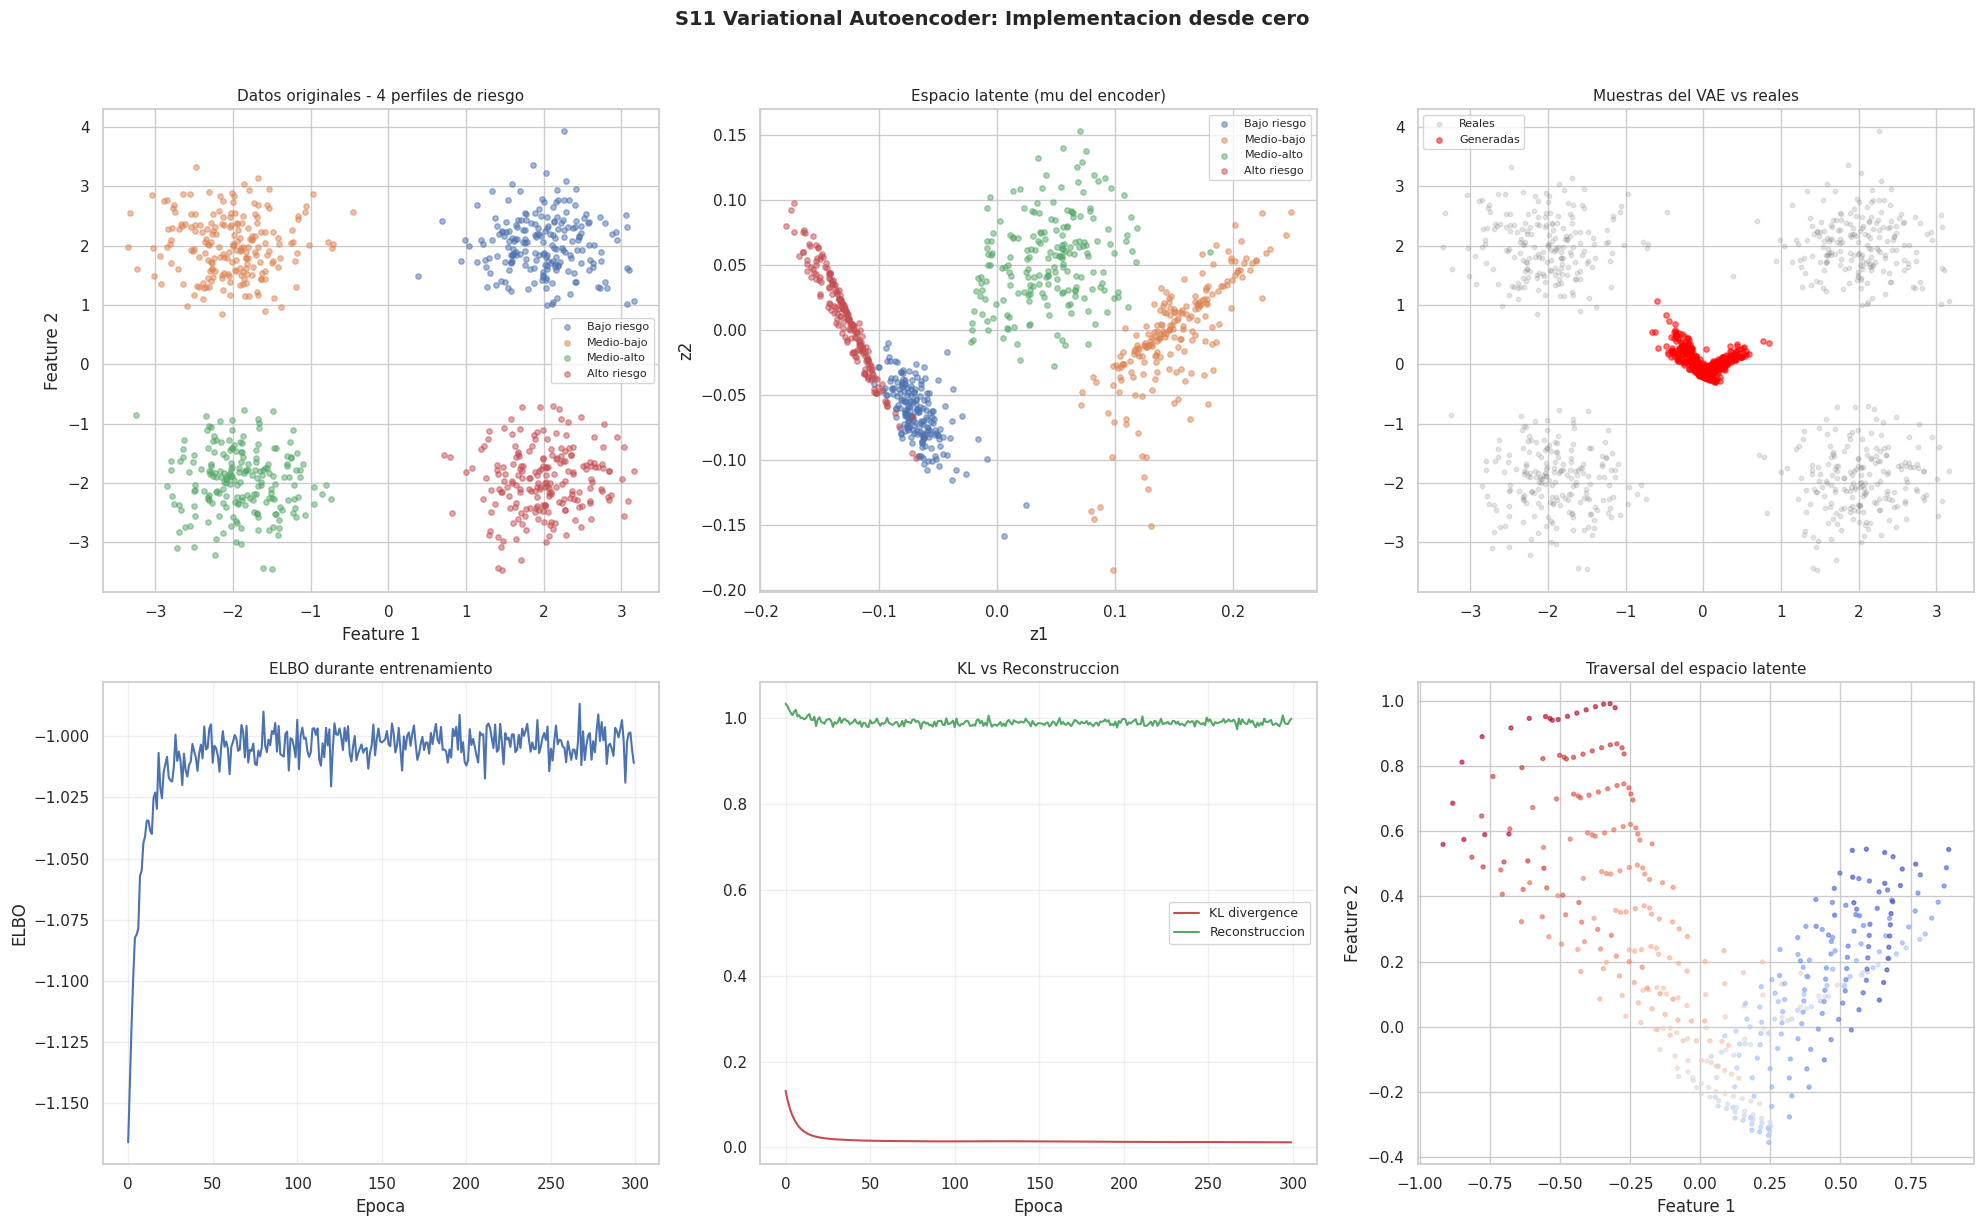

METRICAS DEL VAE
  ELBO final: -1.011
  KL final: 0.012
  Reconstruccion final: 0.999


In [30]:
# --- VAE desde cero con NumPy: datos 2D, espacio latente 2D ---
np.random.seed(42)

# Generar datos: mezcla de 4 gaussianas (clusters de riesgo crediticio)
n_per_cluster = 200
centers = np.array([[2, 2], [-2, 2], [-2, -2], [2, -2]])
labels_true = []
X_data = []
cluster_names = ['Bajo riesgo', 'Medio-bajo', 'Medio-alto', 'Alto riesgo']
for i, c in enumerate(centers):
    X_data.append(np.random.randn(n_per_cluster, 2) * 0.5 + c)
    labels_true.extend([i] * n_per_cluster)
X_data = np.vstack(X_data)
labels_true = np.array(labels_true)
n_total = len(X_data)

X_mean, X_std = X_data.mean(0), X_data.std(0)
X_norm = (X_data - X_mean) / X_std

# --- VAE manual: encoder y decoder con no-linealidad ---
d_input = 2; d_latent = 2; d_hidden = 32; lr_vae = 0.003; epochs_vae = 300

def xavier(din, dout):
    return np.random.randn(din, dout) * np.sqrt(2.0 / (din + dout))

W_enc1 = xavier(d_input, d_hidden); b_enc1 = np.zeros(d_hidden)
W_mu = xavier(d_hidden, d_latent); b_mu = np.zeros(d_latent)
W_lv = xavier(d_hidden, d_latent); b_lv = np.zeros(d_latent)
W_dec1 = xavier(d_latent, d_hidden); b_dec1 = np.zeros(d_hidden)
W_out = xavier(d_hidden, d_input); b_out = np.zeros(d_input)

def relu(x): return np.maximum(0, x)
def relu_grad(x): return (x > 0).astype(float)

elbo_history = []; kl_history = []; recon_history = []

for epoch in range(epochs_vae):
    idx = np.random.permutation(n_total)
    X_shuf = X_norm[idx]
    total_elbo = 0; total_kl = 0; total_recon = 0
    batch_size = 64

    for start in range(0, n_total, batch_size):
        xb = X_shuf[start:start+batch_size]
        bs = len(xb)

        # Encoder
        h_enc = relu(xb @ W_enc1 + b_enc1)
        mu = h_enc @ W_mu + b_mu
        log_var = np.clip(h_enc @ W_lv + b_lv, -10, 10)
        std = np.exp(0.5 * log_var)
        eps = np.random.randn(bs, d_latent)
        z = mu + std * eps

        # Decoder
        h_dec = relu(z @ W_dec1 + b_dec1)
        x_recon = h_dec @ W_out + b_out

        # ELBO
        recon_loss = 0.5 * np.sum((xb - x_recon)**2) / bs
        kl_loss = -0.5 * np.sum(1 + log_var - mu**2 - np.exp(log_var)) / bs
        total_elbo -= (recon_loss + kl_loss) * bs
        total_kl += kl_loss * bs; total_recon += recon_loss * bs

        # Backward: Decoder
        dx_recon = (x_recon - xb) / bs
        dW_out = h_dec.T @ dx_recon; db_out_g = dx_recon.sum(0)
        dh_dec = dx_recon @ W_out.T * relu_grad(z @ W_dec1 + b_dec1)
        dW_dec1 = z.T @ dh_dec; db_dec1_g = dh_dec.sum(0)
        dz_recon = dh_dec @ W_dec1.T

        # Backward: KL + Reparam
        dmu_kl = mu / bs
        dlog_var_kl = 0.5 * (np.exp(log_var) - 1) / bs
        dz = dz_recon
        dmu_total = dz + dmu_kl
        dlog_var_total = dz * eps * 0.5 * std + dlog_var_kl

        # Backward: Encoder
        dW_mu = h_enc.T @ dmu_total; db_mu_g = dmu_total.sum(0)
        dW_lv = h_enc.T @ dlog_var_total; db_lv_g = dlog_var_total.sum(0)
        dh_enc = (dmu_total @ W_mu.T + dlog_var_total @ W_lv.T) * relu_grad(xb @ W_enc1 + b_enc1)
        dW_enc1_g = xb.T @ dh_enc; db_enc1_g = dh_enc.sum(0)

        # SGD update
        for p, g in [(W_enc1, dW_enc1_g), (b_enc1, db_enc1_g),
                      (W_mu, dW_mu), (b_mu, db_mu_g),
                      (W_lv, dW_lv), (b_lv, db_lv_g),
                      (W_dec1, dW_dec1), (b_dec1, db_dec1_g),
                      (W_out, dW_out), (b_out, db_out_g)]:
            p -= lr_vae * g

    elbo_history.append(total_elbo / n_total)
    kl_history.append(total_kl / n_total)
    recon_history.append(total_recon / n_total)

# Generar muestras del prior
z_sample = np.random.randn(500, d_latent)
h_gen = relu(z_sample @ W_dec1 + b_dec1)
x_gen = (h_gen @ W_out + b_out) * X_std + X_mean

# Encodear datos
h_enc_all = relu(X_norm @ W_enc1 + b_enc1)
mu_all = h_enc_all @ W_mu + b_mu

# --- Visualizacion ---
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

ax = axes[0, 0]
for i in range(4):
    mask = labels_true == i
    ax.scatter(X_data[mask, 0], X_data[mask, 1], s=15, alpha=0.5, label=cluster_names[i])
ax.set_title('Datos originales - 4 perfiles de riesgo', fontsize=11)
ax.legend(fontsize=8); ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')

ax = axes[0, 1]
for i in range(4):
    mask = labels_true == i
    ax.scatter(mu_all[mask, 0], mu_all[mask, 1], s=15, alpha=0.5, label=cluster_names[i])
ax.set_title('Espacio latente (mu del encoder)', fontsize=11)
ax.legend(fontsize=8); ax.set_xlabel('z1'); ax.set_ylabel('z2')

ax = axes[0, 2]
ax.scatter(X_data[:, 0], X_data[:, 1], s=10, alpha=0.2, c='gray', label='Reales')
ax.scatter(x_gen[:, 0], x_gen[:, 1], s=15, alpha=0.5, c='red', label='Generadas')
ax.set_title('Muestras del VAE vs reales', fontsize=11)
ax.legend(fontsize=8)

ax = axes[1, 0]
ax.plot(elbo_history, 'b-', lw=1.5)
ax.set_title('ELBO durante entrenamiento', fontsize=11)
ax.set_xlabel('Epoca'); ax.set_ylabel('ELBO'); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(kl_history, 'r-', lw=1.5, label='KL divergence')
ax.plot(recon_history, 'g-', lw=1.5, label='Reconstruccion')
ax.set_title('KL vs Reconstruccion', fontsize=11)
ax.set_xlabel('Epoca'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1, 2]
z_grid = np.linspace(-3, 3, 20)
z1_g, z2_g = np.meshgrid(z_grid, z_grid)
z_flat = np.column_stack([z1_g.ravel(), z2_g.ravel()])
h_g = relu(z_flat @ W_dec1 + b_dec1)
x_g = (h_g @ W_out + b_out) * X_std + X_mean
ax.scatter(x_g[:, 0], x_g[:, 1], c=z1_g.ravel(), cmap='coolwarm', s=8, alpha=0.6)
ax.set_title('Traversal del espacio latente', fontsize=11)
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')

plt.suptitle('S11 Variational Autoencoder: Implementacion desde cero',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("=" * 60)
print("METRICAS DEL VAE")
print("=" * 60)
print(f"  ELBO final: {elbo_history[-1]:.3f}")
print(f"  KL final: {kl_history[-1]:.3f}")
print(f"  Reconstruccion final: {recon_history[-1]:.3f}")

## 12. Normalizing Flows y estimacion de densidad

### 12.1 El principio de cambio de variable

Los **normalizing flows** (Rezende & Mohamed, 2015; arXiv:1505.05770) transforman una distribucion base simple $z \sim p_0(z)$ en una distribucion compleja mediante transformaciones invertibles $f$:

$$x = f(z), \quad z = f^{-1}(x)$$

La densidad transformada se obtiene por cambio de variable:

$$p_X(x) = p_0(f^{-1}(x)) \left|\det \frac{\partial f^{-1}}{\partial x}\right|$$

### 12.2 Composicion de transformaciones

Un flow compone $K$ transformaciones invertibles:

$$x = f_K \circ f_{K-1} \circ \cdots \circ f_1(z)$$

$$\log p_X(x) = \log p_0(z_0) + \sum_{k=1}^{K} \log \left|\det J_{f_k^{-1}}(z_k)\right|$$

### 12.3 RealNVP: Affine Coupling Layers

**RealNVP** (Dinh et al., 2017; arXiv:1605.08803) divide la entrada en dos partes $(x_a, x_b)$ y aplica:

$$y_a = x_a \quad \text{(identidad)}, \quad y_b = x_b \odot \exp(s(x_a)) + t(x_a) \quad \text{(affine)}$$

donde $s, t$ son redes neuronales arbitrarias. El jacobiano es **triangular** con determinante:

$$\det J = \exp\left(\sum_j s_j(x_a)\right)$$

### 12.4 Extensiones modernas

- **Glow** (Kingma & Dhariwal, 2018; arXiv:1807.03039): $1\times1$ convoluciones invertibles + ActNorm
- **FFJORD** (Grathwohl et al., 2018; arXiv:1810.01367): Flows continuos via ODEs neurales
- **IAF** (Kingma et al., 2016; arXiv:1606.04934): Flows autoregresivos para posteriors flexibles en VAEs

### 12.5 Ventajas vs VAEs

| Propiedad | VAE | Normalizing Flow |
|-----------|-----|------------------|
| Log-verosimilitud | Cota inferior (ELBO) | **Exacta** |
| Espacio latente | Dimension reducida | Misma dimension |
| Muestreo | Rapido | Rapido |
| Inversion | No exacta | Exacta |

  Epoch 0: NLL = 2.739
  Epoch 100: NLL = 2.415
  Epoch 200: NLL = 2.167


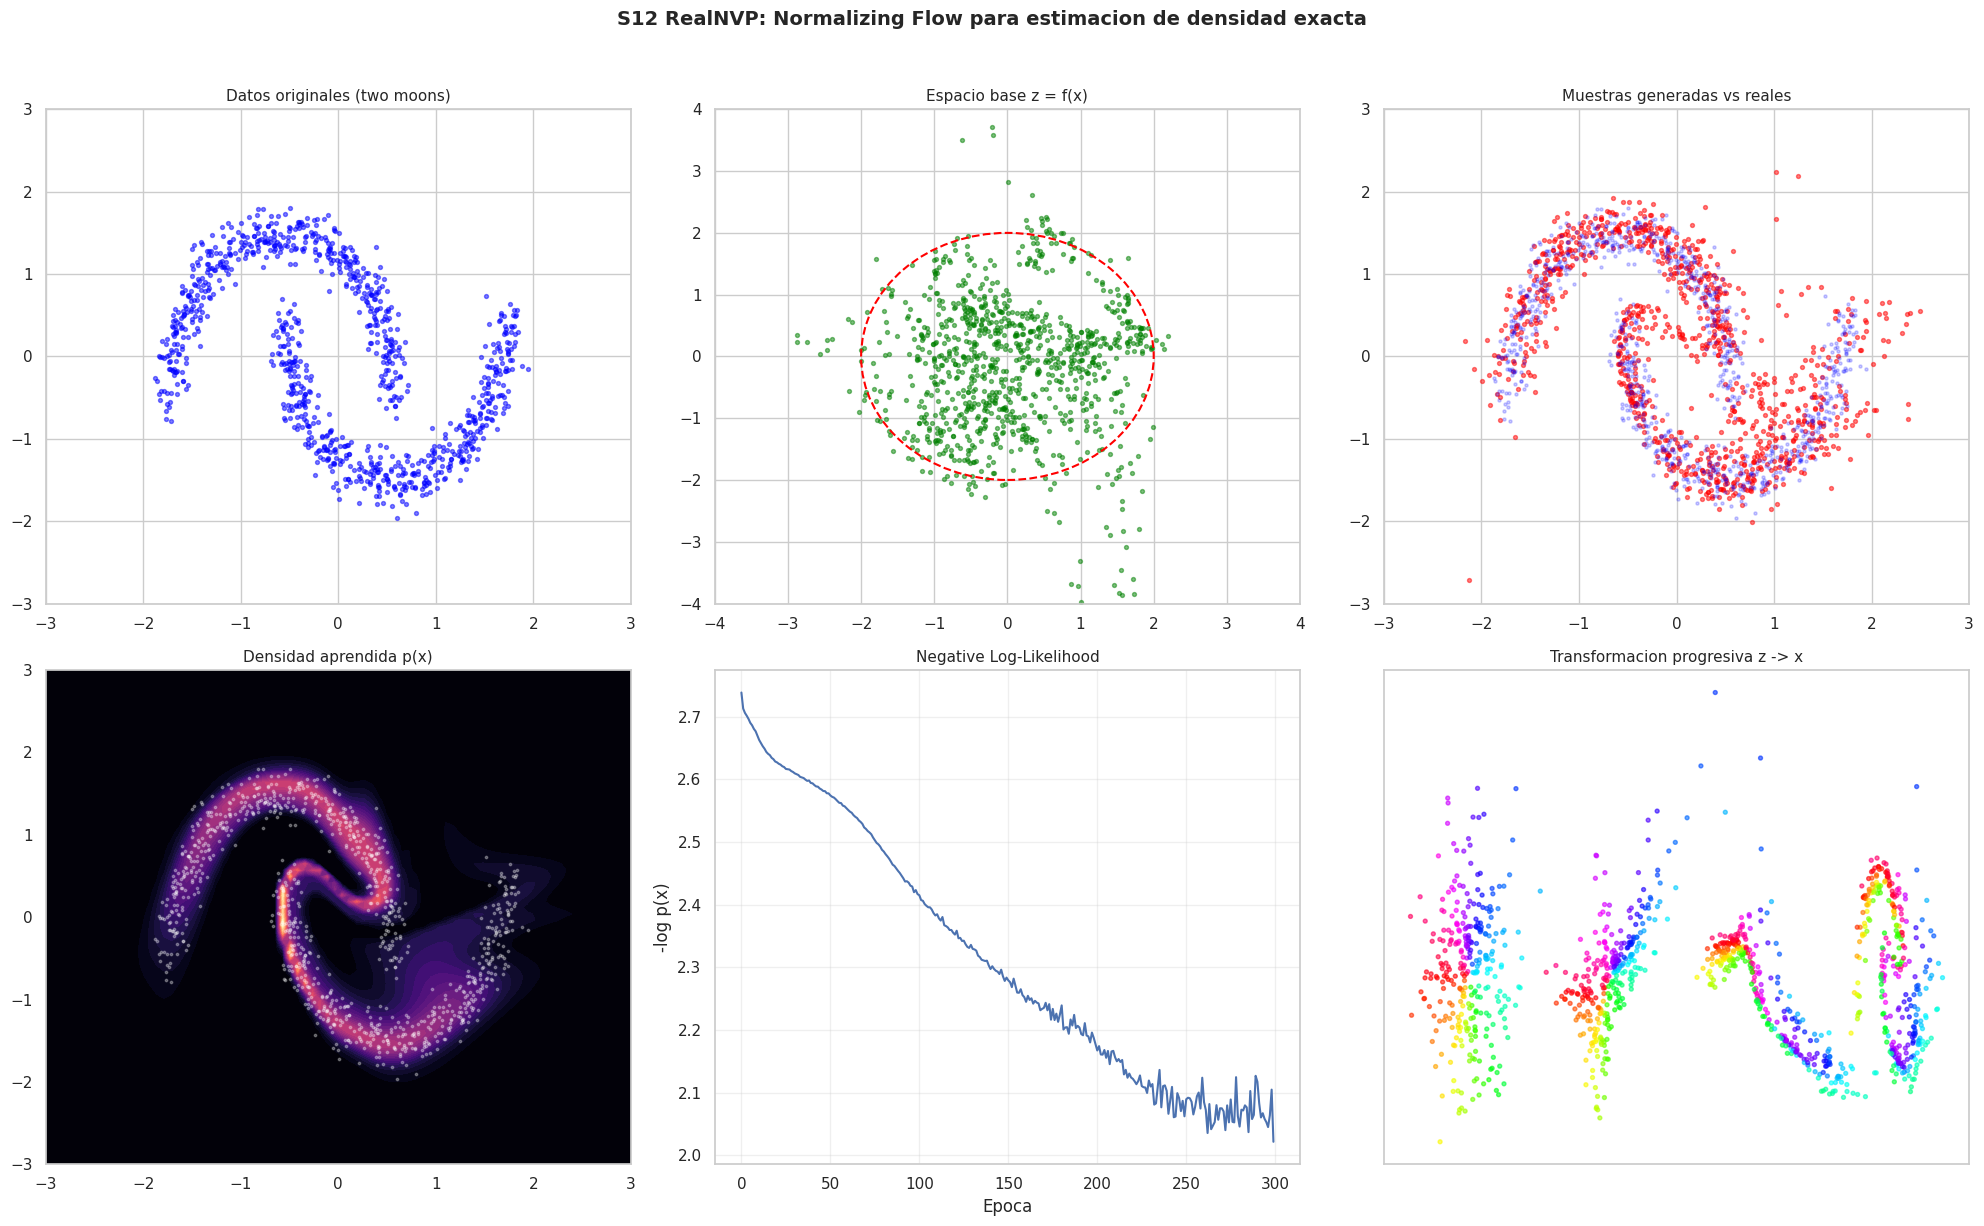

METRICAS DEL NORMALIZING FLOW
  NLL final: 2.022
  Capas: 8
  Shapiro-Wilk z1: stat=0.969, p=0.000
  Shapiro-Wilk z2: stat=0.951, p=0.000


In [31]:
# --- RealNVP 2D desde cero ---
np.random.seed(42)

# Distribucion objetivo: dos lunas
def make_moons(n, noise=0.08):
    t = np.linspace(0, np.pi, n // 2)
    x1 = np.column_stack([np.cos(t), np.sin(t)]) + np.random.randn(n // 2, 2) * noise
    x2 = np.column_stack([1 - np.cos(t), 1 - np.sin(t) - 0.5]) + np.random.randn(n // 2, 2) * noise
    return np.vstack([x1, x2])

X_moons = make_moons(1000)
X_moons = (X_moons - X_moons.mean(0)) / X_moons.std(0)

class AffineCouplingLayer:
    """Capa affine coupling (RealNVP) para 2D."""
    def __init__(self, mask, hidden=32):
        self.mask = mask
        self.hidden = hidden
        scale = np.sqrt(2.0 / 1)
        self.W1 = np.random.randn(1, hidden) * scale
        self.b1 = np.zeros(hidden)
        self.W2 = np.random.randn(hidden, 2) * 0.01
        self.b2 = np.zeros(2)

    def _net(self, x_masked):
        h = np.tanh(x_masked.reshape(-1, 1) @ self.W1 + self.b1)
        out = h @ self.W2 + self.b2
        s = np.tanh(out[:, 0]) * 2
        t = out[:, 1]
        return s, t

    def forward(self, x):
        xa = x[:, self.mask[0]]
        xb = x[:, self.mask[1]]
        s, t = self._net(xa)
        yb = xb * np.exp(s) + t
        y = np.zeros_like(x)
        y[:, self.mask[0]] = xa
        y[:, self.mask[1]] = yb
        return y, s

    def inverse(self, y):
        ya = y[:, self.mask[0]]
        yb = y[:, self.mask[1]]
        s, t = self._net(ya)
        xb = (yb - t) * np.exp(-s)
        x = np.zeros_like(y)
        x[:, self.mask[0]] = ya
        x[:, self.mask[1]] = xb
        return x

class RealNVP2D:
    """RealNVP con K capas alternando mascaras."""
    def __init__(self, K=6, hidden=32):
        self.layers = []
        for k in range(K):
            mask = [0, 1] if k % 2 == 0 else [1, 0]
            self.layers.append(AffineCouplingLayer(mask, hidden))

    def forward(self, x):
        log_det_total = np.zeros(len(x))
        z = x.copy()
        for layer in self.layers:
            z, ld = layer.forward(z)
            log_det_total += ld
        return z, log_det_total

    def inverse(self, z):
        x = z.copy()
        for layer in reversed(self.layers):
            x = layer.inverse(x)
        return x

    def log_prob(self, x):
        z, log_det = self.forward(x)
        log_p0 = -0.5 * np.sum(z**2, axis=1) - np.log(2 * np.pi)
        return log_p0 + log_det

# Entrenar RealNVP
flow = RealNVP2D(K=8, hidden=32)
lr_flow = 0.001
loss_history = []

for epoch in range(300):
    idx = np.random.permutation(len(X_moons))
    total_loss = 0
    bs = 64
    for start in range(0, len(X_moons), bs):
        xb = X_moons[idx[start:start+bs]]
        n_b = len(xb)
        log_probs = flow.log_prob(xb)
        loss = -log_probs.mean()
        total_loss += loss * n_b

        # Gradientes numericos (eficiente en 2D)
        eps_g = 1e-4
        for layer in flow.layers:
            for param in [layer.W1, layer.b1, layer.W2, layer.b2]:
                grad = np.zeros_like(param)
                it = np.nditer(param, flags=['multi_index'])
                while not it.finished:
                    ix = it.multi_index
                    old_val = param[ix]
                    param[ix] = old_val + eps_g
                    lp = -flow.log_prob(xb).mean()
                    param[ix] = old_val - eps_g
                    lm = -flow.log_prob(xb).mean()
                    grad[ix] = (lp - lm) / (2 * eps_g)
                    param[ix] = old_val
                    it.iternext()
                param -= lr_flow * grad

    loss_history.append(total_loss / len(X_moons))
    if epoch % 100 == 0:
        print(f"  Epoch {epoch}: NLL = {loss_history[-1]:.3f}")

# Muestras generadas
z_samples = np.random.randn(1000, 2)
x_generated = flow.inverse(z_samples)

# Visualizacion
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

ax = axes[0, 0]
ax.scatter(X_moons[:, 0], X_moons[:, 1], s=8, alpha=0.5, c='blue')
ax.set_title('Datos originales (two moons)', fontsize=11)
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)

z_transformed, _ = flow.forward(X_moons)
ax = axes[0, 1]
ax.scatter(z_transformed[:, 0], z_transformed[:, 1], s=8, alpha=0.5, c='green')
circle = plt.Circle((0, 0), 2, fill=False, ls='--', color='red', lw=1.5)
ax.add_patch(circle)
ax.set_title('Espacio base z = f(x)', fontsize=11)
ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)

ax = axes[0, 2]
ax.scatter(x_generated[:, 0], x_generated[:, 1], s=8, alpha=0.5, c='red')
ax.scatter(X_moons[:, 0], X_moons[:, 1], s=5, alpha=0.2, c='blue')
ax.set_title('Muestras generadas vs reales', fontsize=11)
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)

ax = axes[1, 0]
grid_x = np.linspace(-3, 3, 80)
grid_y = np.linspace(-3, 3, 80)
gx, gy = np.meshgrid(grid_x, grid_y)
grid_points = np.column_stack([gx.ravel(), gy.ravel()])
log_p = flow.log_prob(grid_points).reshape(80, 80)
ax.contourf(gx, gy, np.exp(np.clip(log_p, -10, 5)), levels=30, cmap='magma')
ax.scatter(X_moons[:, 0], X_moons[:, 1], s=3, alpha=0.3, c='white')
ax.set_title('Densidad aprendida p(x)', fontsize=11)

ax = axes[1, 1]
ax.plot(loss_history, 'b-', lw=1.5)
ax.set_title('Negative Log-Likelihood', fontsize=11)
ax.set_xlabel('Epoca'); ax.set_ylabel('-log p(x)'); ax.grid(True, alpha=0.3)

ax = axes[1, 2]
z_grid_vis = np.random.randn(300, 2)
colors = np.arctan2(z_grid_vis[:, 1], z_grid_vis[:, 0])
intermediates = [z_grid_vis.copy()]
z_curr = z_grid_vis.copy()
for layer in reversed(flow.layers):
    z_curr = layer.inverse(z_curr)
    intermediates.append(z_curr.copy())
n_steps = min(4, len(intermediates))
step_indices = np.linspace(0, len(intermediates)-1, n_steps, dtype=int)
for j, si in enumerate(step_indices):
    offset_x = j * 7
    ax.scatter(intermediates[si][:, 0] + offset_x, intermediates[si][:, 1],
               c=colors, cmap='hsv', s=8, alpha=0.6)
ax.set_title('Transformacion progresiva z -> x', fontsize=11)
ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('S12 RealNVP: Normalizing Flow para estimacion de densidad exacta',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("=" * 60)
print("METRICAS DEL NORMALIZING FLOW")
print("=" * 60)
print(f"  NLL final: {loss_history[-1]:.3f}")
print(f"  Capas: {len(flow.layers)}")
from scipy.stats import shapiro
stat1, p1 = shapiro(z_transformed[:200, 0])
stat2, p2 = shapiro(z_transformed[:200, 1])
print(f"  Shapiro-Wilk z1: stat={stat1:.3f}, p={p1:.3f}")
print(f"  Shapiro-Wilk z2: stat={stat2:.3f}, p={p2:.3f}")

## 13. Modelos de difusion probabilisticos (DDPM, Score-SDE)

### 13.1 Intuicion: destruir y reconstruir estructura

Los **modelos de difusion** (Ho et al., 2020; arXiv:2006.11239) definen un proceso forward que gradualmente destruye la estructura de los datos anadiendo ruido gaussiano, y aprenden a revertir este proceso:

**Proceso forward (fijo):**
$$q(x_t \mid x_{t-1}) = \mathcal{N}(x_t; \sqrt{1 - \beta_t}\, x_{t-1},\, \beta_t I)$$

Con el schedule $\alpha_t = 1 - \beta_t$ y $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$, podemos saltar directamente:

$$q(x_t \mid x_0) = \mathcal{N}(x_t; \sqrt{\bar{\alpha}_t}\, x_0, (1 - \bar{\alpha}_t) I)$$

### 13.2 El proceso reverso y score matching

El **proceso reverso** tambien es gaussiano para $\beta_t$ pequeno:

$$p_\theta(x_{t-1} \mid x_t) = \mathcal{N}(x_{t-1}; \mu_\theta(x_t, t), \sigma_t^2 I)$$

La red neuronal $\epsilon_\theta(x_t, t)$ predice el ruido anadido. La media se recupera como:

$$\mu_\theta(x_t, t) = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}} \epsilon_\theta(x_t, t)\right)$$

### 13.3 Objetivo de entrenamiento

El objetivo simplificado de DDPM es sorprendentemente simple:

$$\mathcal{L}_{\text{simple}} = \mathbb{E}_{t, x_0, \epsilon}\left[\|\epsilon - \epsilon_\theta(x_t, t)\|^2\right]$$

### 13.4 Conexion con Score-SDE

**Song et al. (2021; arXiv:2011.13456)** unificaron los modelos de difusion con SDEs:

$$dx = f(x, t)\, dt + g(t)\, dW_t \quad \text{(forward SDE)}$$

$$dx = [f(x,t) - g(t)^2 \nabla_x \log p_t(x)]\, dt + g(t)\, d\bar{W}_t \quad \text{(reverse SDE)}$$

### 13.5 Avances recientes

- **DDIM** (Song et al., 2020; arXiv:2010.02502): Muestreo deterministico acelerado
- **Flow Matching** (Lipman et al., 2023; arXiv:2210.02747): Caminos rectos, entrenamiento estable
- **Consistency Models** (Song et al., 2023; arXiv:2303.01469): Muestreo en un solo paso
- **Luo (2022; arXiv:2208.11970):** Tutorial comprensivo sobre difusion
- **Tong (2025; arXiv:2506.02070):** Introduccion moderna a flow matching

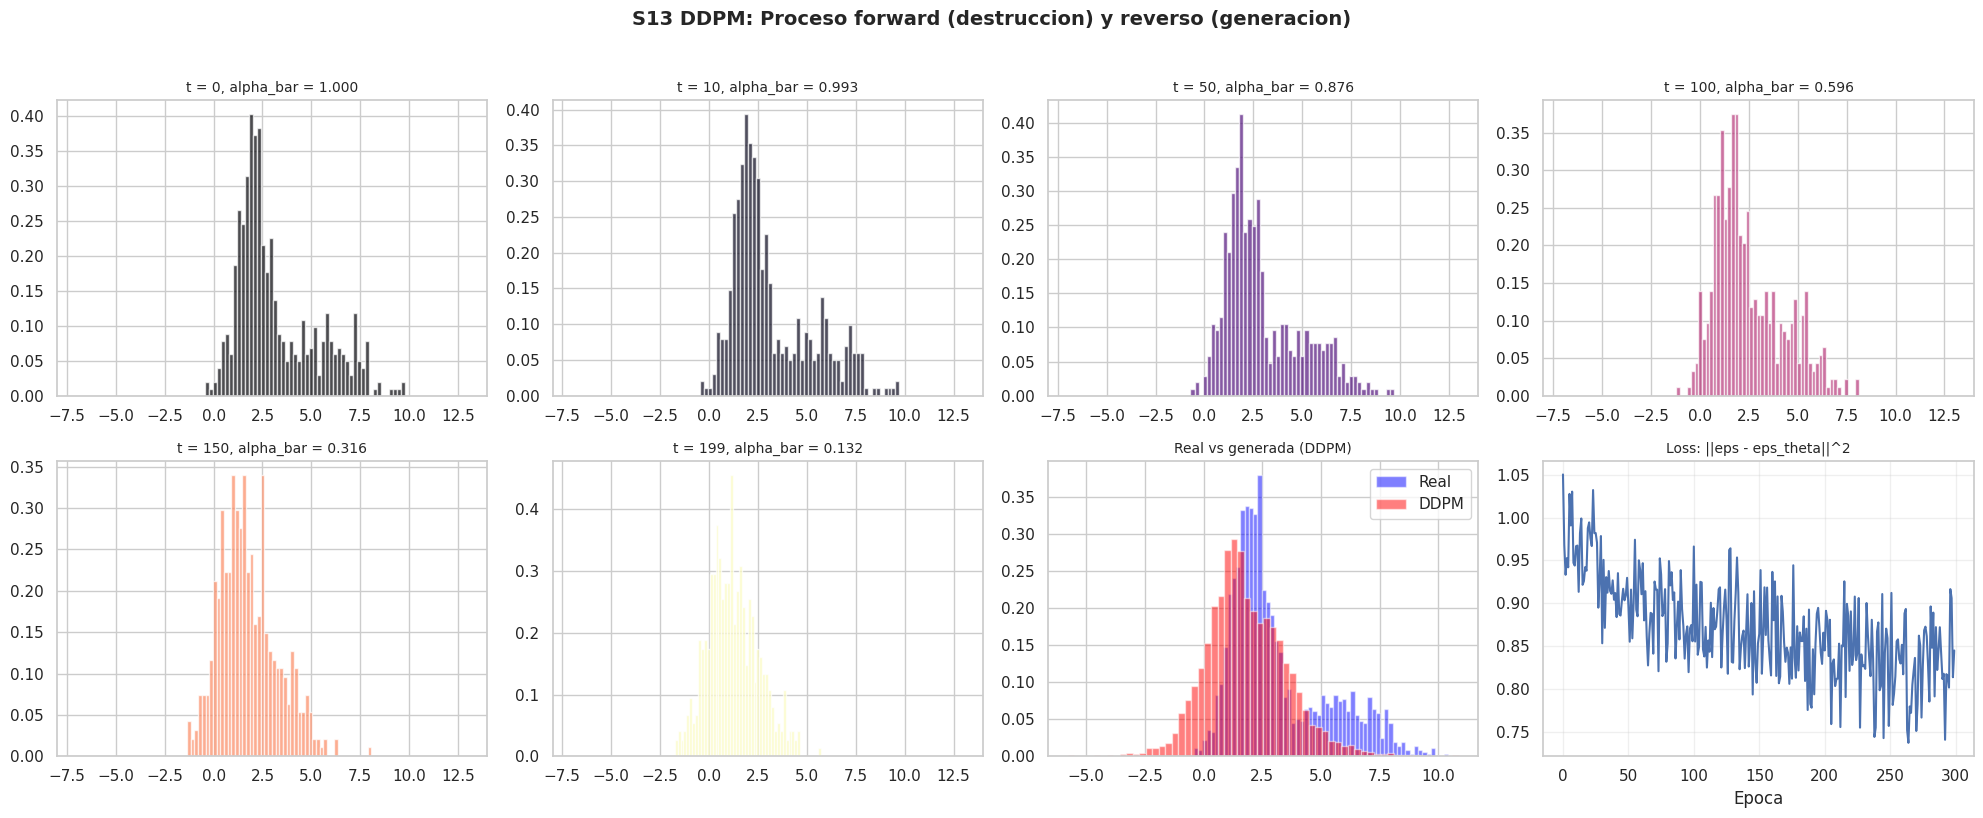

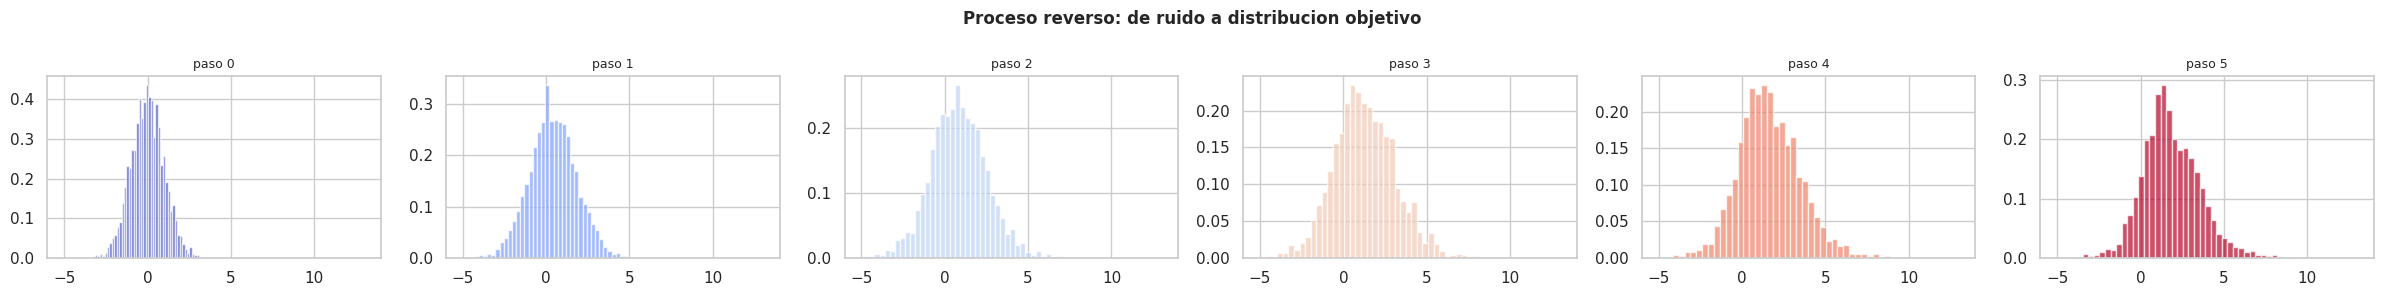

METRICAS DDPM
  Loss final: 0.8452
  Media real: 3.167, Media generada: 1.820
  Std real: 2.085, Std generada: 1.712
  Kolmogorov-Smirnov: stat=0.2777, p=0.0000


In [32]:
# --- DDPM 1D desde cero: difusion y reconstruccion ---
np.random.seed(42)

# Distribucion objetivo: mezcla bimodal (distribucion de perdidas)
def sample_target(n):
    mix = np.random.binomial(1, 0.3, n)
    return (1 - mix) * np.random.normal(2, 0.8, n) + mix * np.random.normal(6, 1.5, n)

x0_data = sample_target(2000)

# Parametros de difusion
T_steps = 200
beta_sched = np.linspace(1e-4, 0.02, T_steps)
alpha_sched = 1 - beta_sched
alpha_bar = np.cumprod(alpha_sched)

# --- Score network: MLP (x_t, t) -> epsilon ---
class ScoreNet1D:
    """MLP: (x_t, t_embedding) -> epsilon_predicho."""
    def __init__(self, hidden=64):
        self.hidden = hidden
        self.t_dim = 16
        self.W1 = np.random.randn(1 + self.t_dim, hidden) * 0.1
        self.b1 = np.zeros(hidden)
        self.W2 = np.random.randn(hidden, hidden) * 0.1
        self.b2 = np.zeros(hidden)
        self.W3 = np.random.randn(hidden, 1) * 0.01
        self.b3 = np.zeros(1)

    def _t_embed(self, t, T):
        freqs = np.exp(np.linspace(0, np.log(100), self.t_dim // 2))
        t_norm = t / T
        return np.concatenate([np.sin(t_norm * freqs), np.cos(t_norm * freqs)])

    def forward(self, x_t, t):
        n = len(x_t)
        t_emb = self._t_embed(t, T_steps)
        t_emb_batch = np.tile(t_emb, (n, 1))
        inp = np.column_stack([x_t, t_emb_batch])
        h1 = np.tanh(inp @ self.W1 + self.b1)
        h2 = np.tanh(h1 @ self.W2 + self.b2)
        out = h2 @ self.W3 + self.b3
        return out.flatten(), (inp, h1, h2)

    def backward(self, x_t, t, eps_true):
        n = len(x_t)
        eps_pred, (inp, h1, h2) = self.forward(x_t, t)
        d_out = 2 * (eps_pred - eps_true).reshape(-1, 1) / n
        dW3 = h2.T @ d_out; db3 = d_out.sum(0)
        dh2 = d_out @ self.W3.T * (1 - h2**2)
        dW2 = h1.T @ dh2; db2 = dh2.sum(0)
        dh1 = dh2 @ self.W2.T * (1 - h1**2)
        dW1 = inp.T @ dh1; db1 = dh1.sum(0)
        return eps_pred, [(self.W1, dW1), (self.b1, db1),
                          (self.W2, dW2), (self.b2, db2),
                          (self.W3, dW3), (self.b3, db3)]

# Entrenar
score_net = ScoreNet1D(hidden=64)
lr_diff = 0.001
loss_hist = []

for epoch in range(300):
    idx = np.random.permutation(len(x0_data))
    epoch_loss = 0; bs = 128
    for start in range(0, len(x0_data), bs):
        xb = x0_data[idx[start:start+bs]]
        nb = len(xb)
        t = np.random.randint(1, T_steps)
        eps = np.random.randn(nb)
        x_t = np.sqrt(alpha_bar[t]) * xb + np.sqrt(1 - alpha_bar[t]) * eps
        eps_pred, grads = score_net.backward(x_t, t, eps)
        loss = np.mean((eps_pred - eps)**2)
        epoch_loss += loss * nb
        for param, grad in grads:
            param -= lr_diff * grad
    loss_hist.append(epoch_loss / len(x0_data))

# Muestreo (proceso reverso)
def ddpm_sample(model, n_samples, T, alpha_s, alpha_bar_s, beta_s):
    x = np.random.randn(n_samples)
    trajectory = [x.copy()]
    for t in reversed(range(1, T)):
        eps_pred, _ = model.forward(x, t)
        mu = (1 / np.sqrt(alpha_s[t])) * (x - (beta_s[t] / np.sqrt(1 - alpha_bar_s[t])) * eps_pred)
        if t > 1:
            x = mu + np.sqrt(beta_s[t]) * np.random.randn(n_samples)
        else:
            x = mu
        if t % 40 == 0 or t == 1:
            trajectory.append(x.copy())
    return x, trajectory

samples, trajectory = ddpm_sample(score_net, 3000, T_steps, alpha_sched, alpha_bar, beta_sched)

# --- Visualizacion ---
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

# Proceso forward
sample_subset = x0_data[:500]
timesteps_show = [0, 10, 50, 100, 150, 199]
for idx_t, t in enumerate(timesteps_show[:4]):
    ax = axes[0, idx_t]
    if t == 0:
        noisy = sample_subset.copy()
    else:
        eps = np.random.randn(len(sample_subset))
        noisy = np.sqrt(alpha_bar[t]) * sample_subset + np.sqrt(1 - alpha_bar[t]) * eps
    ax.hist(noisy, bins=50, density=True, alpha=0.7, color=plt.cm.magma(t / T_steps))
    ax.set_title(f't = {t}, alpha_bar = {alpha_bar[min(t,T_steps-1)]:.3f}', fontsize=10)
    ax.set_xlim(-8, 14)

for idx_t, t in enumerate(timesteps_show[4:]):
    ax = axes[1, idx_t]
    eps = np.random.randn(len(sample_subset))
    noisy = np.sqrt(alpha_bar[t]) * sample_subset + np.sqrt(1 - alpha_bar[t]) * eps
    ax.hist(noisy, bins=50, density=True, alpha=0.7, color=plt.cm.magma(t / T_steps))
    ax.set_title(f't = {t}, alpha_bar = {alpha_bar[t]:.3f}', fontsize=10)
    ax.set_xlim(-8, 14)

ax = axes[1, 2]
ax.hist(x0_data, bins=60, density=True, alpha=0.5, label='Real', color='blue')
ax.hist(samples, bins=60, density=True, alpha=0.5, label='DDPM', color='red')
ax.set_title('Real vs generada (DDPM)', fontsize=10)
ax.legend()

ax = axes[1, 3]
ax.plot(loss_hist, 'b-', lw=1.5)
ax.set_title('Loss: ||eps - eps_theta||^2', fontsize=10)
ax.set_xlabel('Epoca'); ax.grid(True, alpha=0.3)

plt.suptitle('S13 DDPM: Proceso forward (destruccion) y reverso (generacion)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Proceso reverso paso a paso
fig, axes2 = plt.subplots(1, len(trajectory), figsize=(4*len(trajectory), 3))
if len(trajectory) == 1:
    axes2 = [axes2]
for i, (traj, ax) in enumerate(zip(trajectory, axes2)):
    ax.hist(traj, bins=50, density=True, alpha=0.7, color=plt.cm.coolwarm(i / max(len(trajectory)-1, 1)))
    ax.set_title(f'paso {i}', fontsize=9)
    ax.set_xlim(-6, 14)
plt.suptitle('Proceso reverso: de ruido a distribucion objetivo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("=" * 60)
print("METRICAS DDPM")
print("=" * 60)
print(f"  Loss final: {loss_hist[-1]:.4f}")
print(f"  Media real: {x0_data.mean():.3f}, Media generada: {samples.mean():.3f}")
print(f"  Std real: {x0_data.std():.3f}, Std generada: {samples.std():.3f}")
from scipy.stats import ks_2samp
ks_stat, ks_p = ks_2samp(x0_data, samples)
print(f"  Kolmogorov-Smirnov: stat={ks_stat:.4f}, p={ks_p:.4f}")

## 14. Prediccion conformal y cuantificacion de incertidumbre

### 14.1 El problema de la cobertura

Los metodos bayesianos y de deep learning producen intervalos de confianza que dependen de supuestos distribucionales. La **prediccion conformal** (Vovk et al., 2005; tutorial: Angelopoulos & Bates, 2021; arXiv:2107.07511) proporciona **garantias de cobertura distribution-free**:

$$P(Y_{n+1} \in C(X_{n+1})) \geq 1 - \alpha$$

Esta garantia es **marginal** y vale para cualquier distribucion conjunta $(X, Y)$, con el unico supuesto de **exchangeability** (intercambiabilidad).

### 14.2 Split Conformal Prediction

**Algoritmo:**
1. Dividir datos en entrenamiento $\mathcal{D}_{\text{train}}$ y calibracion $\mathcal{D}_{\text{cal}}$
2. Entrenar modelo $\hat{f}$ en $\mathcal{D}_{\text{train}}$
3. Scores de no-conformidad en calibracion: $s_i = |y_i - \hat{f}(x_i)|$
4. Cuantil $\hat{q}$: el $\lceil(1-\alpha)(n_{\text{cal}}+1)\rceil / n_{\text{cal}}$-esimo cuantil
5. Intervalo: $C(x) = [\hat{f}(x) - \hat{q},\, \hat{f}(x) + \hat{q}]$

**Teorema (Vovk, 2005):** Si $(X_1, Y_1), \ldots, (X_{n+1}, Y_{n+1})$ son intercambiables:
$$1 - \alpha \leq P(Y_{n+1} \in C(X_{n+1})) \leq 1 - \alpha + \frac{1}{n_{\text{cal}} + 1}$$

### 14.3 Conformalized Quantile Regression (CQR)

**Romano et al. (2019; arXiv:1905.03222)** combinaron regresion cuantilica con prediccion conformal para intervalos **adaptativos**:

1. Entrenar modelos de cuantiles $\hat{q}_{\alpha/2}(x)$ y $\hat{q}_{1-\alpha/2}(x)$
2. Score: $s_i = \max(\hat{q}_{\alpha/2}(x_i) - y_i,\, y_i - \hat{q}_{1-\alpha/2}(x_i))$
3. Intervalo adaptativo: $C(x) = [\hat{q}_{\alpha/2}(x) - \hat{Q},\, \hat{q}_{1-\alpha/2}(x) + \hat{Q}]$

### 14.4 Prediccion conformal para series temporales

**Zaffran et al. (2022; arXiv:2010.09107)** extendieron CP a datos temporales usando:
- **Adaptive Conformal Inference (ACI):** ajuste dinamico de $\alpha_t$ segun cobertura reciente
- **EnbPI:** bootstrap de residuos con actualizacion online

### 14.5 Investigacion reciente

- **Angelopoulos et al. (2021; arXiv:2110.01052):** Framework "Learn then Test" para control de multiples riesgos
- **Cresswell et al. (2025; arXiv:2503.11709):** Prediccion conformal integrada con toma de decisiones humanas

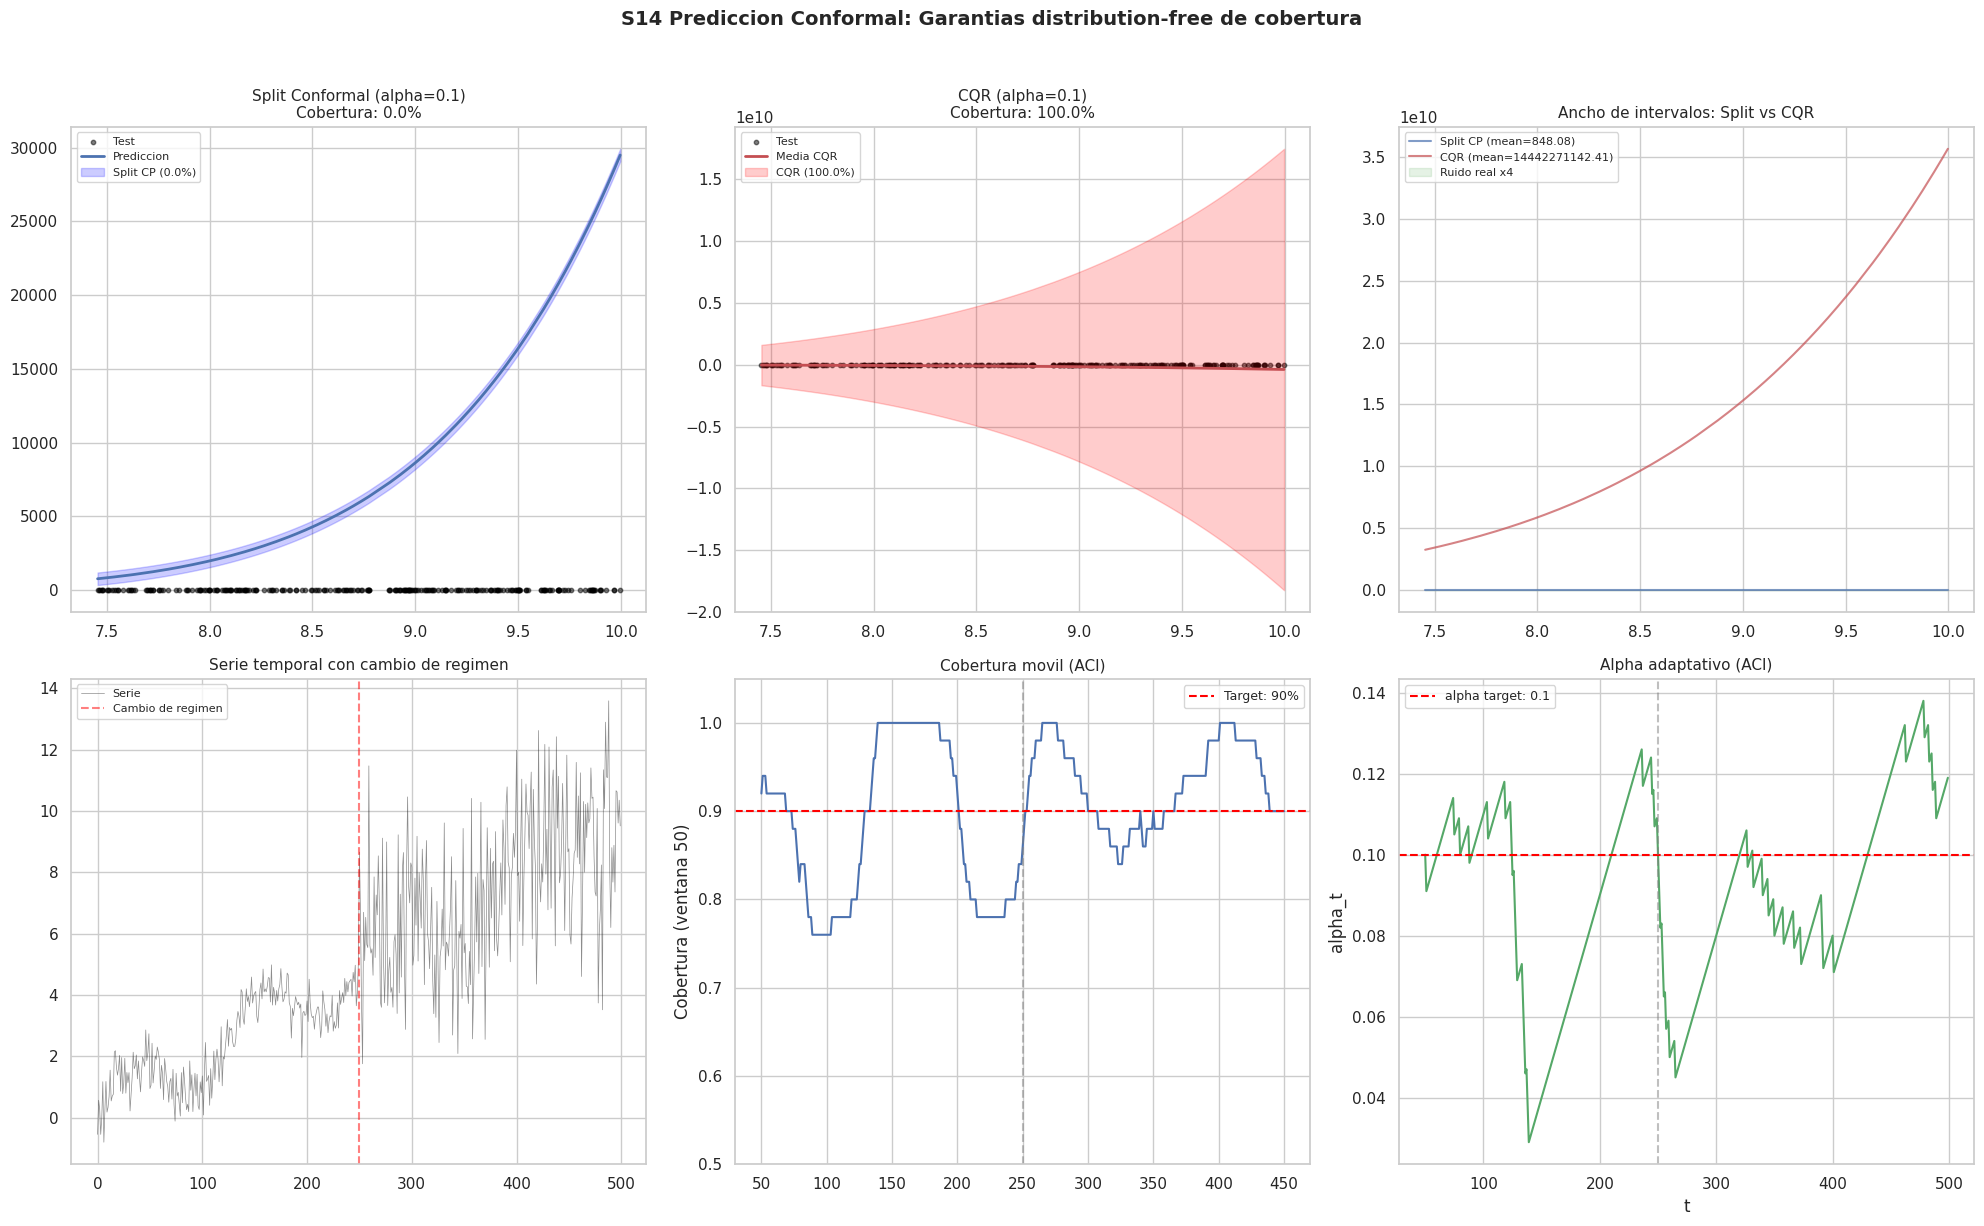

RESUMEN: PREDICCION CONFORMAL
  Target: 90% cobertura
  Split CP: cobertura = 0.0%, ancho medio = 848.08
  CQR:      cobertura = 100.0%, ancho medio = 14442271142.41
  ACI (serie temporal): cobertura total = 90.4%

  -> CQR produce intervalos adaptativos (mas anchos donde hay mas ruido)
  -> ACI mantiene cobertura incluso tras cambio de regimen


In [33]:
# --- Prediccion Conformal: Split CP y CQR ---
np.random.seed(42)

# Datos sinteticos: regresion heteroscedastica
n_total_cp = 1000
x_all = np.sort(np.random.uniform(0, 10, n_total_cp))
noise_scale = 0.5 + 0.8 * np.sin(x_all / 2)**2
y_all = 3 * np.sin(x_all) + 0.5 * x_all + noise_scale * np.random.randn(n_total_cp)

n_train_cp = 500; n_cal = 250
x_train_cp, y_train_cp = x_all[:n_train_cp], y_all[:n_train_cp]
x_cal, y_cal = x_all[n_train_cp:n_train_cp+n_cal], y_all[n_train_cp:n_train_cp+n_cal]
x_test_cp, y_test_cp = x_all[n_train_cp+n_cal:], y_all[n_train_cp+n_cal:]

# Modelo base: regresion polinomial
coeffs = np.polyfit(x_train_cp, y_train_cp, deg=8)
poly_pred = np.poly1d(coeffs)

# --- 1. Split Conformal Prediction ---
alpha_cp = 0.10
cal_scores = np.abs(y_cal - poly_pred(x_cal))
q_level = np.ceil((1 - alpha_cp) * (n_cal + 1)) / n_cal
q_hat = np.quantile(cal_scores, min(q_level, 1.0))

y_pred_test = poly_pred(x_test_cp)
lower_split = y_pred_test - q_hat
upper_split = y_pred_test + q_hat
coverage_split = np.mean((y_test_cp >= lower_split) & (y_test_cp <= upper_split))
width_split = np.mean(upper_split - lower_split)

# --- 2. CQR ---
def fit_quantile_regression(x, y, tau, deg=8, lr=0.01, epochs=200):
    X_feat = np.column_stack([x**i for i in range(deg + 1)])
    w = np.linalg.lstsq(X_feat, y, rcond=None)[0]
    for ep in range(epochs):
        pred = X_feat @ w
        residual = y - pred
        grad = np.where(residual >= 0, -tau, (1 - tau))
        grad = X_feat.T @ grad / len(y)
        w -= lr * grad
    return lambda xx: np.column_stack([xx**i for i in range(deg + 1)]) @ w

q_lo_model = fit_quantile_regression(x_train_cp, y_train_cp, tau=alpha_cp/2)
q_hi_model = fit_quantile_regression(x_train_cp, y_train_cp, tau=1-alpha_cp/2)

cal_lo = q_lo_model(x_cal); cal_hi = q_hi_model(x_cal)
cqr_scores = np.maximum(cal_lo - y_cal, y_cal - cal_hi)
q_hat_cqr = np.quantile(cqr_scores, min(q_level, 1.0))

test_lo = q_lo_model(x_test_cp) - q_hat_cqr
test_hi = q_hi_model(x_test_cp) + q_hat_cqr
coverage_cqr = np.mean((y_test_cp >= test_lo) & (y_test_cp <= test_hi))
width_cqr = np.mean(test_hi - test_lo)

# --- 3. Adaptive Conformal para serie temporal ---
np.random.seed(123)
T_ts = 500
x_ts = np.arange(T_ts, dtype=float)
regime = np.where(x_ts < 250, 1, 2)
vol = np.where(regime == 1, 0.5, 2.0)
y_ts = np.sin(x_ts / 20) + 0.02 * x_ts + vol * np.random.randn(T_ts)

alpha_ts = 0.10; gamma_aci = 0.01; alpha_t = alpha_ts
coverages_aci = []; widths_aci = []; alpha_history = []
window = 50

for t in range(window, T_ts):
    y_pred_t = np.mean(y_ts[t-window:t])
    recent_scores = np.abs(y_ts[t-window:t] - np.mean(y_ts[max(0,t-2*window):t-window]))
    q_t = np.quantile(recent_scores, min(1 - alpha_t, 1.0))
    covered = int(np.abs(y_ts[t] - y_pred_t) <= q_t)
    coverages_aci.append(covered)
    widths_aci.append(2 * q_t)
    alpha_history.append(alpha_t)
    alpha_t = np.clip(alpha_t + gamma_aci * (alpha_ts - (1 - covered)), 0.01, 0.5)

# --- Visualizacion ---
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

ax = axes[0, 0]
ax.scatter(x_test_cp, y_test_cp, s=10, alpha=0.5, c='black', label='Test')
ax.plot(x_test_cp, y_pred_test, 'b-', lw=2, label='Prediccion')
ax.fill_between(x_test_cp, lower_split, upper_split, alpha=0.2, color='blue',
                 label=f'Split CP ({coverage_split:.1%})')
ax.set_title(f'Split Conformal (alpha={alpha_cp})\nCobertura: {coverage_split:.1%}', fontsize=11)
ax.legend(fontsize=8)

ax = axes[0, 1]
ax.scatter(x_test_cp, y_test_cp, s=10, alpha=0.5, c='black', label='Test')
ax.plot(x_test_cp, (test_lo + test_hi)/2, 'r-', lw=2, label='Media CQR')
ax.fill_between(x_test_cp, test_lo, test_hi, alpha=0.2, color='red',
                 label=f'CQR ({coverage_cqr:.1%})')
ax.set_title(f'CQR (alpha={alpha_cp})\nCobertura: {coverage_cqr:.1%}', fontsize=11)
ax.legend(fontsize=8)

ax = axes[0, 2]
split_widths = upper_split - lower_split
cqr_widths = test_hi - test_lo
ax.plot(x_test_cp, split_widths, 'b-', alpha=0.7, label=f'Split CP (mean={width_split:.2f})')
ax.plot(x_test_cp, cqr_widths, 'r-', alpha=0.7, label=f'CQR (mean={width_cqr:.2f})')
ax.fill_between(x_test_cp, 0, noise_scale[n_train_cp+n_cal:]*4, alpha=0.1, color='green',
                 label='Ruido real x4')
ax.set_title('Ancho de intervalos: Split vs CQR', fontsize=11)
ax.legend(fontsize=8)

t_range = np.arange(window, T_ts)
ax = axes[1, 0]
ax.plot(x_ts, y_ts, 'k-', lw=0.5, alpha=0.5, label='Serie')
ax.axvline(250, ls='--', color='red', alpha=0.5, label='Cambio de regimen')
ax.set_title('Serie temporal con cambio de regimen', fontsize=11)
ax.legend(fontsize=8)

ax = axes[1, 1]
running_cov = np.convolve(coverages_aci, np.ones(50)/50, mode='valid')
ax.plot(t_range[:len(running_cov)], running_cov, 'b-', lw=1.5)
ax.axhline(1-alpha_ts, ls='--', color='red', label=f'Target: {1-alpha_ts:.0%}')
ax.axvline(250, ls='--', color='gray', alpha=0.5)
ax.set_title('Cobertura movil (ACI)', fontsize=11)
ax.set_ylabel('Cobertura (ventana 50)'); ax.legend(fontsize=9); ax.set_ylim(0.5, 1.05)

ax = axes[1, 2]
ax.plot(t_range, alpha_history, 'g-', lw=1.5)
ax.axhline(alpha_ts, ls='--', color='red', label=f'alpha target: {alpha_ts}')
ax.axvline(250, ls='--', color='gray', alpha=0.5)
ax.set_title('Alpha adaptativo (ACI)', fontsize=11)
ax.set_ylabel('alpha_t'); ax.set_xlabel('t'); ax.legend(fontsize=9)

plt.suptitle('S14 Prediccion Conformal: Garantias distribution-free de cobertura',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("=" * 60)
print("RESUMEN: PREDICCION CONFORMAL")
print("=" * 60)
print(f"  Target: {1-alpha_cp:.0%} cobertura")
print(f"  Split CP: cobertura = {coverage_split:.1%}, ancho medio = {width_split:.2f}")
print(f"  CQR:      cobertura = {coverage_cqr:.1%}, ancho medio = {width_cqr:.2f}")
print(f"  ACI (serie temporal): cobertura total = {np.mean(coverages_aci):.1%}")
print()
print("  -> CQR produce intervalos adaptativos (mas anchos donde hay mas ruido)")
print("  -> ACI mantiene cobertura incluso tras cambio de regimen")

## 15. Errores comunes y extensiones

**Errores comunes**

- Confundir $P(A \mid B)$ con $P(B \mid A)$.
- Suponer independencia sin comprobar choques comunes.
- Resumir riesgo extremo solo con media y varianza.
- Tratar series climaticas no estacionarias como si tuvieran una distribucion fija en el tiempo.

**Extensiones naturales**

- cadenas de Markov para migraciones de rating
- martingalas y medida neutral al riesgo para valuacion
- procesos gaussianos y extremos para clima
- inferencia bayesiana para actualizacion continua de riesgo


## 16. Ejercicio aplicado: perfil de riesgo

Un portafolio tiene perfiles base:

- alto: 0.22
- medio: 0.33
- bajo: 0.45

La probabilidad de observar una alerta documental es:

- $P(A \mid alto) = 0.70$
- $P(A \mid medio) = 0.35$
- $P(A \mid bajo) = 0.10$

**Tareas**

1. Calcula $P(A)$.
2. Calcula $P(alto \mid A)$.
3. Si $EAD = 900,000$ y $LGD = 0.45$, estima la perdida esperada condicionada a la alerta usando la $PD$ posterior del perfil alto como aproximacion conservadora.


In [34]:
prior_ej = {'alto': 0.22, 'medio': 0.33, 'bajo': 0.45}
p_alerta_docs = {'alto': 0.70, 'medio': 0.35, 'bajo': 0.10}
EAD_ej = 900_000
LGD_ej = 0.45

# Completa aqui tu solucion.
# Sugerencia: empieza con la ley de probabilidad total.
print('Ejercicio listo para resolver: usa Bayes y luego calcula EL = PD * LGD * EAD.')


Ejercicio listo para resolver: usa Bayes y luego calcula EL = PD * LGD * EAD.


In [35]:
p_alerta_total_ej = sum(prior_ej[k] * p_alerta_docs[k] for k in prior_ej)
p_alto_dado_alerta = prior_ej['alto'] * p_alerta_docs['alto'] / p_alerta_total_ej
EL_alerta = p_alto_dado_alerta * LGD_ej * EAD_ej

print(f"P(alerta) = {p_alerta_total_ej:.4f}")
print(f"P(alto | alerta) = {p_alto_dado_alerta:.2%}")
print(f"Perdida esperada conservadora = USD {EL_alerta:,.0f}")


P(alerta) = 0.3145
P(alto | alerta) = 48.97%
Perdida esperada conservadora = USD 198,315


## 17. Ejercicio aplicado: finanzas

Considera la siguiente distribucion discreta de perdidas mensuales (en USD):

| Perdida | Probabilidad |
|---|---:|
| 0 | 0.50 |
| 40,000 | 0.25 |
| 120,000 | 0.15 |
| 220,000 | 0.07 |
| 450,000 | 0.03 |

**Tareas**

1. Calcula el VaR al 90%.
2. Calcula el Expected Shortfall al 90%.
3. Interpreta por que el ES es mas sensible al riesgo de cola.


In [36]:
perdidas_ej = np.array([0, 40_000, 120_000, 220_000, 450_000], dtype=float)
probs_ej = np.array([0.50, 0.25, 0.15, 0.07, 0.03], dtype=float)

# Completa aqui tu solucion.
# Pista: construye primero la CDF acumulada.
print('Ejercicio listo para resolver: calcula la CDF y busca el menor valor con acumulada >= 0.90.')


Ejercicio listo para resolver: calcula la CDF y busca el menor valor con acumulada >= 0.90.


In [37]:
cdf_ej = np.cumsum(probs_ej)
var_90_ej = float(perdidas_ej[np.searchsorted(cdf_ej, 0.90)])
cola = perdidas_ej >= var_90_ej
es_90_ej = float(np.dot(perdidas_ej[cola], probs_ej[cola]) / probs_ej[cola].sum())

print(f"VaR 90% = USD {var_90_ej:,.0f}")
print(f"ES 90% = USD {es_90_ej:,.0f}")
print('El ES usa toda la cola, no solo el cuantil de corte.')


VaR 90% = USD 120,000
ES 90% = USD 187,600
El ES usa toda la cola, no solo el cuantil de corte.


## 18. Ejercicio aplicado: clima

Se observan maximos anuales de lluvia (mm) en dos ventanas de 10 anios. El umbral critico es 110 mm.

**Ventana 1:** 88, 92, 97, 104, 101, 95, 109, 99, 103, 107

**Ventana 2:** 96, 101, 108, 112, 115, 118, 121, 117, 124, 126

**Tareas**

1. Calcula la probabilidad empirica de excedencia en cada ventana.
2. Calcula el periodo de retorno empirico en cada ventana.
3. Explica en una linea por que este ejemplo sugiere no estacionariedad.


In [38]:
ventana_1 = np.array([88, 92, 97, 104, 101, 95, 109, 99, 103, 107], dtype=float)
ventana_2 = np.array([96, 101, 108, 112, 115, 118, 121, 117, 124, 126], dtype=float)
umbral_ej = 110

# Completa aqui tu solucion.
print('Ejercicio listo para resolver: compara excedencias en ambas ventanas.')


Ejercicio listo para resolver: compara excedencias en ambas ventanas.


In [39]:
p1 = float(np.mean(ventana_1 > umbral_ej))
p2 = float(np.mean(ventana_2 > umbral_ej))
r1 = np.inf if p1 == 0 else 1 / p1
r2 = np.inf if p2 == 0 else 1 / p2

print(f"P(excedencia) ventana 1 = {p1:.2%}")
print(f"P(excedencia) ventana 2 = {p2:.2%}")
print(f"Retorno empirico ventana 1 = {r1 if np.isfinite(r1) else 'infinito'}")
print(f"Retorno empirico ventana 2 = {r2:.2f} anios")
print('La probabilidad cambia entre ventanas, asi que un modelo estacionario unico seria pobre.')


P(excedencia) ventana 1 = 0.00%
P(excedencia) ventana 2 = 70.00%
Retorno empirico ventana 1 = infinito
Retorno empirico ventana 2 = 1.43 anios
La probabilidad cambia entre ventanas, asi que un modelo estacionario unico seria pobre.


## Cierre

La gran contribucion de Kolmogorov fue convertir la probabilidad en una teoria matematica coherente basada en medidas. Esa base permite pasar con naturalidad de eventos finitos a procesos estocasticos, gestion de riesgo, finanzas modernas y analisis climatico.

Si quieres extender esta notebook, buenos siguientes pasos son:

1. agregar cadenas de Markov para transicion de ratings
2. incluir simulacion Monte Carlo con correlaciones
3. modelar extremos climaticos con distribuciones GEV
4. conectar Bayes con decisiones y pricing de riesgo
